# Multi-parameter route-order comparison

This notebook extends the validated size-ratio-one pilot by applying the same
within-parameter experiment to five rotating-drum simulations.

For each parameter case independently:

1. the first stationary drum cycle is used to construct the POD bases;
2. the second cycle is retained for blocked validation;
3. held-out truth is orthogonally projected at ranks 0, 8, 14, 27 and 100;
4. two routes are compared:
   - DEM particles → coarse-grained fields → POD;
   - DEM particles → particle-coordinate POD → coarse-grained fields.

This is a representation and cycle-repeatability experiment. It is not yet a
parameter-prediction experiment because each case uses a basis learned from the
first cycle of that same parameter case.

The completed size-ratio-one result from Notebook 11 is retained as a regression
test. No additional multi-gigabyte particle file will be scanned until that
regression case has passed.

### Re-execution note

The compact particle artifacts and per-case result checkpoints are reusable. Their configuration and SHA-256 digests are checked before reuse. Cells tagged `long-running` recompute POD and coarse-graining results; cells tagged `raw-data` may scan a multi-gigabyte `.data` file only when its validated compact cache is absent.


In [11]:
from pathlib import Path
import hashlib
import json
import platform
import sys

import numpy as np
import pandas as pd
from IPython.display import display


# Support launching Jupyter from either the repository root
# or the notebooks directory.
REPO_ROOT = Path.cwd().resolve()

if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

if not (REPO_ROOT / "results").is_dir():
    raise RuntimeError(
        "Repository root could not be identified. "
        f"Current directory: {Path.cwd().resolve()}"
    )


RAW_INVENTORY_PATH = (
    REPO_ROOT
    / "results"
    / "tables"
    / "raw_particle_file_inventory.csv"
)

PILOT_COMPACT_PATH = (
    REPO_ROOT
    / "data"
    / "interim"
    / "particle_positions_ratio_1_000000_num_1.npz"
)

PILOT_MANIFEST_PATH = (
    REPO_ROOT
    / "results"
    / "tables"
    / "particle_snapshot_representation_ratio_1_000000_num_1.json"
)

PILOT_CG_PATH = (
    REPO_ROOT
    / "data"
    / "raw"
    / "CG_field_phi_small"
    / "rotating_drum_bidisperse_size_ratio_1_000000_num_1.stat"
)

PILOT_AVERAGE_RESULTS_PATH = (
    REPO_ROOT
    / "results"
    / "tables"
    / "route_order_comparison_ratio_1_000000_num_1.csv"
)

PILOT_TIME_RESULTS_PATH = (
    REPO_ROOT
    / "results"
    / "tables"
    / "route_order_time_resolved_ratio_1_000000_num_1.csv"
)


LOCAL_DATA_ROOT = (
    REPO_ROOT
    / "data"
)

CLOUD_DATA_ROOT = (
    Path.home()
    / "Library"
    / "CloudStorage"
    / "OneDrive-TheUniversityofManchester"
    / "Anthony Thornton's files - data"
    / "particle_simulation_data"
)

CACHE_DIRECTORY = (
    REPO_ROOT
    / "data"
    / "interim"
    / "multi_parameter_route_order"
)

MULTI_TABLE_DIRECTORY = (
    REPO_ROOT
    / "results"
    / "tables"
    / "multi_parameter_route_order"
)

MULTI_FIGURE_DIRECTORY = (
    REPO_ROOT
    / "results"
    / "figures"
    / "multi_parameter_route_order"
)


STATIONARY_TIME_MIN = 1377.0

SELECTED_RANKS = (
    0,
    8,
    14,
    27,
    100,
)

ANCHOR_TARGETS = np.array(
    [
        1.00,
        1.25,
        1.50,
        1.75,
        2.00,
    ],
    dtype=np.float64,
)

LUCY_CUTOFF = 3.0

AXIAL_DOMAIN_MIN = -5.0
AXIAL_DOMAIN_MAX = 5.0

AXIAL_AVERAGING_LENGTH = (
    AXIAL_DOMAIN_MAX
    - AXIAL_DOMAIN_MIN
)

SMALL_SPECIES = 1
PHYSICAL_NEGATIVE_TOLERANCE = -1e-4

# The .data radius column is serialized to
# 10 decimal places. Half a final decimal unit
# is therefore the expected rounding uncertainty.
RADIUS_SERIALISATION_ATOL = 5.1e-11

required_inputs = pd.DataFrame(
    [
        {
            "input": "raw inventory",
            "path": RAW_INVENTORY_PATH,
        },
        {
            "input": "pilot compact artifact",
            "path": PILOT_COMPACT_PATH,
        },
        {
            "input": "pilot representation manifest",
            "path": PILOT_MANIFEST_PATH,
        },
        {
            "input": "full-window MercuryCG reference",
            "path": PILOT_CG_PATH,
        },
        {
            "input": "pilot time-averaged results",
            "path": PILOT_AVERAGE_RESULTS_PATH,
        },
        {
            "input": "pilot time-resolved results",
            "path": PILOT_TIME_RESULTS_PATH,
        },
    ]
)

required_inputs["exists"] = [
    path.is_file()
    for path in required_inputs["path"]
]

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Repository root:", REPO_ROOT)
print("Cloud data root available:", CLOUD_DATA_ROOT.is_dir())
print("\nRequired inputs:")

display(
    required_inputs.assign(
        path=required_inputs["path"].astype(str)
    )
)

assert required_inputs["exists"].all()
assert SELECTED_RANKS == (0, 8, 14, 27, 100)

Python: 3.12.1
Platform: macOS-15.7.5-x86_64-i386-64bit
Repository root: /Users/rallen/Documents/msc-rom-particle-systems
Cloud data root available: True

Required inputs:


,input,path,exists
0,raw inventory,/Users/rallen/Documents/msc-rom-particle-syste...,True
1,pilot compact artifact,/Users/rallen/Documents/msc-rom-particle-syste...,True
2,pilot representation manifest,/Users/rallen/Documents/msc-rom-particle-syste...,True
3,full-window MercuryCG reference,/Users/rallen/Documents/msc-rom-particle-syste...,True
4,pilot time-averaged results,/Users/rallen/Documents/msc-rom-particle-syste...,True
5,pilot time-resolved results,/Users/rallen/Documents/msc-rom-particle-syste...,True


## Case selection and artifact resolution

Select five training-set size-ratio anchors, identify the required particle, energy and restart artifacts, and prefer local files over OneDrive placeholders when both are available.


In [2]:
raw_inventory = pd.read_csv(
    RAW_INVENTORY_PATH
)

required_inventory_columns = {
    "data_group",
    "split",
    "size_ratio",
    "simulation_number",
    "filename",
    "extension",
    "logical_size_bytes",
    "relative_path",
}

missing_inventory_columns = (
    required_inventory_columns
    - set(raw_inventory.columns)
)

if missing_inventory_columns:
    raise ValueError(
        "Inventory is missing columns: "
        f"{sorted(missing_inventory_columns)}"
    )


training_data_cases = (
    raw_inventory.loc[
        raw_inventory["data_group"].eq(
            "raw_simulation_files"
        )
        & raw_inventory["extension"].eq(
            ".data"
        )
        & raw_inventory["split"].eq(
            "training"
        )
        & raw_inventory["size_ratio"].notna()
        & raw_inventory[
            "simulation_number"
        ].notna()
    ]
    .copy()
)

training_data_cases["size_ratio"] = (
    pd.to_numeric(
        training_data_cases["size_ratio"],
        errors="raise",
    )
)

training_data_cases[
    "simulation_number"
] = (
    pd.to_numeric(
        training_data_cases[
            "simulation_number"
        ],
        errors="raise",
    )
    .astype(int)
)

training_data_cases = (
    training_data_cases
    .sort_values("size_ratio")
    .reset_index(drop=True)
)


selected_rows = []

for target_ratio in ANCHOR_TARGETS:
    nearest_index = (
        training_data_cases["size_ratio"]
        .sub(target_ratio)
        .abs()
        .idxmin()
    )

    selected_row = (
        training_data_cases.loc[
            nearest_index
        ]
        .copy()
    )

    selected_row[
        "target_ratio"
    ] = target_ratio

    selected_row[
        "distance_from_target"
    ] = abs(
        selected_row["size_ratio"]
        - target_ratio
    )

    selected_rows.append(
        selected_row
    )


case_plan = (
    pd.DataFrame(selected_rows)
    .drop_duplicates(
        subset=[
            "size_ratio",
            "simulation_number",
        ]
    )
    .sort_values("size_ratio")
    .reset_index(drop=True)
)

case_plan["case_id"] = [
    (
        f"ratio_{ratio:.6f}_num_{number}"
        .replace(".", "_")
    )
    for ratio, number in zip(
        case_plan["size_ratio"],
        case_plan["simulation_number"],
    )
]

case_plan["role"] = np.where(
    np.isclose(
        case_plan["size_ratio"],
        1.0,
        rtol=0.0,
        atol=1e-12,
    ),
    "pilot regression",
    "parameter sweep",
)

case_plan["logical_size_GiB"] = (
    case_plan["logical_size_bytes"]
    / 1024**3
)


selected_keys = case_plan[
    [
        "case_id",
        "split",
        "size_ratio",
        "simulation_number",
    ]
].copy()

selected_keys["case_key"] = [
    f"{ratio:.6f}|{int(number)}"
    for ratio, number in zip(
        selected_keys["size_ratio"],
        selected_keys["simulation_number"],
    )
]


required_extensions = {
    ".data": "particle_data",
    ".ene": "energy",
    ".restart": "restart",
}

raw_artifact_candidates = (
    raw_inventory.loc[
        raw_inventory["data_group"].eq(
            "raw_simulation_files"
        )
        & raw_inventory["extension"].isin(
            required_extensions
        )
        & raw_inventory["size_ratio"].notna()
        & raw_inventory[
            "simulation_number"
        ].notna()
    ]
    .copy()
)

raw_artifact_candidates[
    "case_key"
] = [
    f"{float(ratio):.6f}|{int(number)}"
    for ratio, number in zip(
        raw_artifact_candidates[
            "size_ratio"
        ],
        raw_artifact_candidates[
            "simulation_number"
        ],
    )
]


artifact_manifest = (
    selected_keys.merge(
        raw_artifact_candidates[
            [
                "split",
                "case_key",
                "filename",
                "extension",
                "logical_size_bytes",
                "relative_path",
            ]
        ],
        on=[
            "split",
            "case_key",
        ],
        how="left",
        validate="one_to_many",
    )
)

artifact_manifest[
    "artifact_kind"
] = (
    artifact_manifest["extension"]
    .map(required_extensions)
)

artifact_manifest = (
    artifact_manifest[
        [
            "case_id",
            "size_ratio",
            "simulation_number",
            "artifact_kind",
            "filename",
            "extension",
            "logical_size_bytes",
            "relative_path",
        ]
    ]
    .sort_values(
        [
            "case_id",
            "artifact_kind",
        ]
    )
    .reset_index(drop=True)
)

artifact_counts = (
    artifact_manifest
    .groupby(
        [
            "case_id",
            "artifact_kind",
        ]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "particle_data",
            "energy",
            "restart",
        ],
        fill_value=0,
    )
)


print("Selected parameter cases:")

display(
    case_plan[
        [
            "case_id",
            "role",
            "target_ratio",
            "size_ratio",
            "simulation_number",
            "distance_from_target",
            "logical_size_GiB",
        ]
    ].style.format(
        {
            "target_ratio": "{:.6f}",
            "size_ratio": "{:.6f}",
            "distance_from_target": "{:.6f}",
            "logical_size_GiB": "{:.3f}",
        }
    )
)

print(
    "Total selected raw particle size:",
    f"{case_plan['logical_size_GiB'].sum():.3f} GiB",
)

print("\nArtifact counts:")
print(artifact_counts.to_string())


assert len(case_plan) == 5
assert case_plan["case_id"].is_unique
assert len(artifact_manifest) == 15
assert artifact_manifest["filename"].notna().all()
assert artifact_manifest["artifact_kind"].notna().all()
assert (artifact_counts == 1).all().all()

Selected parameter cases:


,case_id,role,target_ratio,size_ratio,simulation_number,distance_from_target,logical_size_GiB
0,ratio_1_000000_num_1,pilot regression,1.000000,1.000000,1,0.000000,1.934
1,ratio_1_252525_num_26,parameter sweep,1.250000,1.252525,26,0.002525,2.083
2,ratio_1_494949_num_50,parameter sweep,1.500000,1.494949,50,0.005051,2.436
3,ratio_1_747475_num_75,parameter sweep,1.750000,1.747475,75,0.002525,2.970
4,ratio_2_000000_num_100,parameter sweep,2.000000,2.000000,100,0.000000,3.663


Total selected raw particle size: 13.087 GiB

Artifact counts:
artifact_kind           particle_data  energy  restart
case_id                                               
ratio_1_000000_num_1                1       1        1
ratio_1_252525_num_26               1       1        1
ratio_1_494949_num_50               1       1        1
ratio_1_747475_num_75               1       1        1
ratio_2_000000_num_100              1       1        1


In [3]:
def safe_is_file(path):
    if path is None:
        return False, None

    try:
        return path.is_file(), None
    except OSError as error:
        return False, repr(error)


required_filenames = set(
    artifact_manifest["filename"]
)

local_file_index = {}

for path in LOCAL_DATA_ROOT.rglob("*"):
    if (
        path.is_file()
        and path.name in required_filenames
    ):
        local_file_index.setdefault(
            path.name,
            [],
        ).append(path.resolve())


resolution_records = []

for row in artifact_manifest.itertuples(
    index=False
):
    local_candidates = (
        local_file_index.get(
            row.filename,
            [],
        )
    )

    if len(local_candidates) > 1:
        raise ValueError(
            f"Multiple local matches found for "
            f"{row.filename}: {local_candidates}"
        )

    local_path = (
        local_candidates[0]
        if local_candidates
        else None
    )

    cloud_path = (
        CLOUD_DATA_ROOT
        / row.relative_path
    )

    local_available, local_error = (
        safe_is_file(local_path)
    )

    cloud_available, cloud_error = (
        safe_is_file(cloud_path)
    )

    if local_available:
        selected_path = local_path
        selected_source = "local repository"

    elif cloud_available:
        selected_path = cloud_path
        selected_source = "OneDrive"

    else:
        selected_path = cloud_path
        selected_source = "unresolved"

    path_available = (
        local_available
        or cloud_available
    )

    if path_available:
        file_stat = selected_path.stat()

        observed_size_bytes = int(
            file_stat.st_size
        )

        allocated_size_bytes = int(
            getattr(
                file_stat,
                "st_blocks",
                0,
            )
            * 512
        )

    else:
        observed_size_bytes = np.nan
        allocated_size_bytes = np.nan

    resolution_records.append(
        {
            "case_id":
                row.case_id,
            "size_ratio":
                row.size_ratio,
            "simulation_number":
                row.simulation_number,
            "artifact_kind":
                row.artifact_kind,
            "selected_source":
                selected_source,
            "path_available":
                path_available,
            "expected_size_MiB":
                row.logical_size_bytes
                / 1024**2,
            "observed_size_MiB":
                observed_size_bytes
                / 1024**2,
            "allocated_size_MiB":
                allocated_size_bytes
                / 1024**2,
            "size_matches_inventory": (
                observed_size_bytes
                == row.logical_size_bytes
                if path_available
                else False
            ),
            "metadata_error":
                cloud_error
                or local_error,
            "selected_path":
                str(selected_path),
        }
    )


resolved_artifacts = pd.DataFrame(
    resolution_records
)

print("Resolved artifact paths:")

print(
    resolved_artifacts[
        [
            "case_id",
            "artifact_kind",
            "selected_source",
            "path_available",
            "expected_size_MiB",
            "allocated_size_MiB",
            "size_matches_inventory",
        ]
    ].to_string(
        index=False,
        formatters={
            "expected_size_MiB":
                "{:.3f}".format,
            "allocated_size_MiB":
                "{:.3f}".format,
        },
    )
)

print(
    "\nResolved artifacts:",
    f"{resolved_artifacts['path_available'].sum()} "
    f"of {len(resolved_artifacts)}",
)

print(
    "All logical sizes match:",
    bool(
        resolved_artifacts[
            "size_matches_inventory"
        ].all()
    ),
)

print(
    "OneDrive placeholder artifacts:",
    int(
        (
            resolved_artifacts[
                "selected_source"
            ].eq("OneDrive")
            & resolved_artifacts[
                "allocated_size_MiB"
            ].eq(0.0)
        ).sum()
    ),
)


assert len(resolved_artifacts) == 15
assert resolved_artifacts[
    "path_available"
].all()
assert resolved_artifacts[
    "size_matches_inventory"
].all()

Resolved artifact paths:
               case_id artifact_kind  selected_source  path_available expected_size_MiB allocated_size_MiB  size_matches_inventory
  ratio_1_000000_num_1        energy local repository            True             0.130              0.133                    True
  ratio_1_000000_num_1 particle_data local repository            True          1980.413           1984.820                    True
  ratio_1_000000_num_1       restart local repository            True            12.018             12.020                    True
 ratio_1_252525_num_26        energy         OneDrive            True             0.130              0.000                    True
 ratio_1_252525_num_26 particle_data         OneDrive            True          2133.460              0.000                    True
 ratio_1_252525_num_26       restart         OneDrive            True            12.583              0.000                    True
 ratio_1_494949_num_50        energy         OneDrive     

## Pilot assets and fixed regression targets

Load the validated size-ratio-one compact representation, the full-window MercuryCG reference and the saved Notebook 11 route-order tables. These provide fixed numerical regression targets before the parameter sweep begins.


In [4]:
def sha256_file(
    path,
    chunk_size=8 * 1024**2,
):
    digest = hashlib.sha256()

    with Path(path).open(
        "rb"
    ) as handle:
        while chunk := handle.read(
            chunk_size
        ):
            digest.update(chunk)

    return digest.hexdigest()


# Load the exact full-window MercuryCG file
# validated in Notebook 11.
continuum_data = np.loadtxt(
    PILOT_CG_PATH,
    skiprows=2,
)

reference_times = np.unique(
    continuum_data[:, 0]
)

reference_x = np.unique(
    continuum_data[:, 1]
)

reference_z = np.unique(
    continuum_data[:, 2]
)

if len(reference_times) != 1:
    raise ValueError(
        "The full-window MercuryCG file must "
        "contain exactly one averaged time."
    )

if (
    len(reference_x) != 100
    or len(reference_z) != 100
):
    raise ValueError(
        "Expected a 100 × 100 grid."
    )

if len(continuum_data) != 100 * 100:
    raise ValueError(
        "Expected exactly 10,000 grid rows."
    )

reference_time = float(
    reference_times[0]
)

reference_phi_small = (
    continuum_data[:, 3]
    .reshape(
        len(reference_x),
        len(reference_z),
    )
)

grid_spacing_x = float(
    np.median(
        np.diff(reference_x)
    )
)

grid_spacing_z = float(
    np.median(
        np.diff(reference_z)
    )
)


with PILOT_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    pilot_manifest = json.load(
        handle
    )

observed_compact_hash = sha256_file(
    PILOT_COMPACT_PATH
)

expected_compact_hash = (
    pilot_manifest[
        "compact_artifact"
    ]["sha256"]
)


with np.load(
    PILOT_COMPACT_PATH,
    allow_pickle=False,
) as compact_data:
    pilot_positions_xyz = (
        compact_data[
            "positions_xyz"
        ].copy()
    )

    pilot_snapshot_times = (
        compact_data[
            "snapshot_times"
        ].copy()
    )

    pilot_particle_radii = (
        compact_data[
            "particle_radii"
        ].copy()
    )

    pilot_species_index = (
        compact_data[
            "species_index"
        ].copy()
    )

    pilot_source_snapshot_numbers = (
        compact_data[
            "source_snapshot_numbers"
        ].copy()
    )

    pilot_source_byte_offsets = (
        compact_data[
            "source_byte_offsets"
        ].copy()
    )


pilot_cycle_boundary_time = float(
    pilot_manifest[
        "physical_cycle_split"
    ]["cycle_boundary_time"]
)

pilot_comparison_mask = (
    pilot_snapshot_times
    <= (
        reference_time
        + 1e-8
    )
)

pilot_training_indices = np.flatnonzero(
    (
        pilot_snapshot_times
        <= pilot_cycle_boundary_time
    )
    & pilot_comparison_mask
)

pilot_validation_indices = np.flatnonzero(
    (
        pilot_snapshot_times
        > pilot_cycle_boundary_time
    )
    & pilot_comparison_mask
)


pilot_case_data = {
    "case_id":
        "ratio_1_000000_num_1",
    "positions_xyz":
        pilot_positions_xyz,
    "snapshot_times":
        pilot_snapshot_times,
    "particle_radii":
        pilot_particle_radii,
    "species_index":
        pilot_species_index,
    "source_snapshot_numbers":
        pilot_source_snapshot_numbers,
    "source_byte_offsets":
        pilot_source_byte_offsets,
    "training_indices":
        pilot_training_indices,
    "validation_indices":
        pilot_validation_indices,
    "comparison_time_max":
        reference_time,
}


pilot_average_results = pd.read_csv(
    PILOT_AVERAGE_RESULTS_PATH
)

pilot_time_results = pd.read_csv(
    PILOT_TIME_RESULTS_PATH
)

rank_100_average = (
    pilot_average_results.loc[
        pd.to_numeric(
            pilot_average_results["rank"]
        ).eq(100)
    ]
    .copy()
)

rank_100_time = (
    pilot_time_results.loc[
        pd.to_numeric(
            pilot_time_results["rank"]
        ).eq(100)
    ]
    .copy()
)


print("MercuryCG reference:", PILOT_CG_PATH.name)
print("Reference time:", reference_time)
print(
    "Grid shape:",
    reference_phi_small.shape,
)
print(
    "Grid spacing:",
    grid_spacing_x,
    grid_spacing_z,
)
print(
    "Reference phi_small range:",
    reference_phi_small.min(),
    "to",
    reference_phi_small.max(),
)

print(
    "\nCompact SHA-256 agrees:",
    observed_compact_hash
    == expected_compact_hash,
)
print(
    "Pilot tensor shape:",
    pilot_positions_xyz.shape,
)
print(
    "Cycle boundary:",
    pilot_cycle_boundary_time,
)
print(
    "Training snapshots:",
    len(pilot_training_indices),
)
print(
    "Validation snapshots:",
    len(pilot_validation_indices),
)
print(
    "Final retained comparison time:",
    pilot_snapshot_times[
        pilot_validation_indices[-1]
    ],
)

print(
    "\nSaved rank-100 time-averaged regression:"
)

display(
    rank_100_average[
        [
            "route",
            "relative_l2_error_percent",
            "correlation",
            "maximum_volume_fraction",
            "minimum_volume_fraction",
        ]
    ]
)

print(
    "Saved rank-100 time-resolved regression:"
)

display(
    rank_100_time[
        [
            "route",
            "spacetime_relative_l2_error_percent",
            "time_averaged_l2_error_percent",
            "mean_spatial_correlation",
            "maximum_volume_fraction",
            "minimum_volume_fraction",
        ]
    ]
)


time_rank_100_lookup = (
    rank_100_time
    .set_index("route")
)

average_rank_100_lookup = (
    rank_100_average
    .set_index("route")
)


assert np.isclose(
    reference_time,
    1720.72,
    rtol=0.0,
    atol=1e-10,
)

assert reference_phi_small.shape == (
    100,
    100,
)

assert np.isclose(
    reference_phi_small.max(),
    0.298251,
    rtol=0.0,
    atol=1e-12,
)

assert (
    observed_compact_hash
    == expected_compact_hash
)

assert pilot_positions_xyz.shape == (
    201,
    10792,
    3,
)

assert np.isfinite(
    pilot_positions_xyz
).all()

assert np.all(
    np.diff(
        pilot_snapshot_times
    )
    > 0
)

assert len(
    pilot_training_indices
) == 101

assert len(
    pilot_validation_indices
) == 99

assert np.isclose(
    time_rank_100_lookup.loc[
        "CG then POD",
        "spacetime_relative_l2_error_percent",
    ],
    9.042421,
    rtol=0.0,
    atol=1e-5,
)

assert np.isclose(
    time_rank_100_lookup.loc[
        "Particle POD then CG",
        "spacetime_relative_l2_error_percent",
    ],
    94.761221,
    rtol=0.0,
    atol=1e-5,
)

assert np.isclose(
    average_rank_100_lookup.loc[
        "CG then POD",
        "relative_l2_error_percent",
    ],
    1.591589,
    rtol=0.0,
    atol=1e-5,
)

assert np.isclose(
    average_rank_100_lookup.loc[
        "Particle POD then CG",
        "relative_l2_error_percent",
    ],
    75.222119,
    rtol=0.0,
    atol=1e-5,
)

MercuryCG reference: rotating_drum_bidisperse_size_ratio_1_000000_num_1.stat
Reference time: 1720.72
Grid shape: (100, 100)
Grid spacing: 0.6600000000000001 0.6600000000000001
Reference phi_small range: 0.0 to 0.298251

Compact SHA-256 agrees: True
Pilot tensor shape: (201, 10792, 3)
Cycle boundary: 1550.2054792863642
Training snapshots: 101
Validation snapshots: 99
Final retained comparison time: 1720.516059

Saved rank-100 time-averaged regression:


,route,relative_l2_error_percent,correlation,maximum_volume_fraction,minimum_volume_fraction
8,CG then POD,1.591589,0.999827,0.301403,-0.000004
9,Particle POD then CG,75.222119,0.773764,0.927647,0.000000


Saved rank-100 time-resolved regression:


,route,spacetime_relative_l2_error_percent,time_averaged_l2_error_percent,mean_spatial_correlation,maximum_volume_fraction,minimum_volume_fraction
8,CG then POD,9.042421,1.591589,0.994424,0.346003,-0.010721
9,Particle POD then CG,94.761221,75.222119,0.727973,2.197808,0.000000


## Parser and cache validation

This stage validates the reusable MercuryDPM file readers against the completed
pilot. It reads only the small pilot energy and restart files. No raw `.data`
file is scanned.

In [6]:
import subprocess


def get_artifact_path(
    case_id,
    artifact_kind,
):
    rows = resolved_artifacts.loc[
        resolved_artifacts[
            "case_id"
        ].eq(case_id)
        & resolved_artifacts[
            "artifact_kind"
        ].eq(artifact_kind)
    ]

    if len(rows) != 1:
        raise ValueError(
            f"Expected one {artifact_kind!r} "
            f"artifact for {case_id!r}; "
            f"found {len(rows)}."
        )

    row = rows.iloc[0]

    if not bool(
        row["path_available"]
    ):
        raise FileNotFoundError(
            row["selected_path"]
        )

    path = Path(
        row["selected_path"]
    )

    if not path.is_file():
        raise FileNotFoundError(path)

    return path


PILOT_CASE_ID = (
    case_plan.loc[
        case_plan["role"].eq(
            "pilot regression"
        ),
        "case_id",
    ]
    .item()
)

cache_probe = (
    CACHE_DIRECTORY
    / "git_ignore_probe.npz"
)

ignore_result = subprocess.run(
    [
        "git",
        "check-ignore",
        "-q",
        str(
            cache_probe.relative_to(
                REPO_ROOT
            )
        ),
    ],
    cwd=REPO_ROOT,
    capture_output=True,
    text=True,
)

cache_is_ignored = (
    ignore_result.returncode == 0
)

if not cache_is_ignored:
    raise RuntimeError(
        "The proposed multi-parameter cache "
        "is not excluded by .gitignore."
    )

CACHE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

MULTI_TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

MULTI_FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


pilot_energy_path = get_artifact_path(
    PILOT_CASE_ID,
    "energy",
)

pilot_restart_path = get_artifact_path(
    PILOT_CASE_ID,
    "restart",
)


print("Pilot case:", PILOT_CASE_ID)
print(
    "Multi-parameter cache ignored by Git:",
    cache_is_ignored,
)
print("Pilot energy file:", pilot_energy_path.name)
print("Pilot restart file:", pilot_restart_path.name)
print("Cache directory:", CACHE_DIRECTORY)
print("Table directory:", MULTI_TABLE_DIRECTORY)
print("Figure directory:", MULTI_FIGURE_DIRECTORY)

assert PILOT_CASE_ID == (
    "ratio_1_000000_num_1"
)

Pilot case: ratio_1_000000_num_1
Multi-parameter cache ignored by Git: True
Pilot energy file: rotating_drum_bidisperse_size_ratio_1_000000_num_1.ene
Pilot restart file: rotating_drum_bidisperse_size_ratio_1_000000_num_1.restart
Cache directory: /Users/rallen/Documents/msc-rom-particle-systems/data/interim/multi_parameter_route_order
Table directory: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/multi_parameter_route_order
Figure directory: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/multi_parameter_route_order


In [7]:
PARTICLE_COLUMNS = [
    "x",
    "y",
    "z",
    "vx",
    "vy",
    "vz",
    "radius",
    "rotation_1",
    "rotation_2",
    "rotation_3",
    "omega_x",
    "omega_y",
    "omega_z",
    "species_index",
]


def scan_particle_data_file(
    path,
    progress_interval=100,
):
    """
    Stream through one MercuryDPM .data file.

    The function records each snapshot's byte
    offset without retaining its particle rows.
    The SHA-256 digest is calculated during the
    same pass to avoid reading the multi-gigabyte
    file twice.
    """
    path = Path(path)

    snapshot_records = []
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        snapshot_number = 0

        while True:
            byte_offset = handle.tell()
            header_line = handle.readline()

            if not header_line:
                break

            digest.update(
                header_line
            )

            header_tokens = (
                header_line.split()
            )

            if len(header_tokens) != 8:
                raise ValueError(
                    f"Expected 8 header values "
                    f"at byte {byte_offset}; "
                    f"found {len(header_tokens)}."
                )

            particle_count = int(
                header_tokens[0]
            )

            snapshot_time = float(
                header_tokens[1]
            )

            bounds = [
                float(value)
                for value
                in header_tokens[2:]
            ]

            for particle_row in range(
                particle_count
            ):
                line = handle.readline()

                if not line:
                    raise EOFError(
                        "Unexpected end of file in "
                        f"snapshot {snapshot_number}, "
                        f"particle row {particle_row}."
                    )

                digest.update(line)

            snapshot_records.append(
                {
                    "snapshot_number":
                        snapshot_number,
                    "byte_offset":
                        byte_offset,
                    "particle_count":
                        particle_count,
                    "time":
                        snapshot_time,
                    "x_min":
                        bounds[0],
                    "y_min":
                        bounds[1],
                    "z_min":
                        bounds[2],
                    "x_max":
                        bounds[3],
                    "y_max":
                        bounds[4],
                    "z_max":
                        bounds[5],
                }
            )

            snapshot_number += 1

            if (
                snapshot_number
                % progress_interval
                == 0
            ):
                print(
                    "Scanned snapshots:",
                    snapshot_number,
                )

    snapshot_index = pd.DataFrame(
        snapshot_records
    )

    return (
        snapshot_index,
        digest.hexdigest(),
    )


def read_particle_snapshot(
    path,
    byte_offset,
):
    """Read one snapshot using a stored byte offset."""
    path = Path(path)

    with path.open("rb") as handle:
        handle.seek(
            int(byte_offset)
        )

        header = (
            handle.readline()
            .split()
        )

        if len(header) != 8:
            raise ValueError(
                "Snapshot header contains "
                f"{len(header)} values; "
                "expected 8."
            )

        particle_count = int(
            header[0]
        )

        snapshot_time = float(
            header[1]
        )

        domain_bounds = np.asarray(
            header[2:8],
            dtype=np.float64,
        )

        values = np.empty(
            (
                particle_count,
                len(PARTICLE_COLUMNS),
            ),
            dtype=np.float64,
        )

        for row_index in range(
            particle_count
        ):
            line = handle.readline()

            if not line:
                raise EOFError(
                    "Unexpected end of file at "
                    f"particle row {row_index}."
                )

            row = np.fromstring(
                line,
                sep=" ",
                dtype=np.float64,
            )

            if row.size != len(
                PARTICLE_COLUMNS
            ):
                raise ValueError(
                    f"Particle row {row_index} "
                    f"contains {row.size} values; "
                    f"expected "
                    f"{len(PARTICLE_COLUMNS)}."
                )

            values[row_index] = row

    metadata = {
        "particle_count":
            particle_count,
        "time":
            snapshot_time,
        "domain_bounds":
            domain_bounds,
    }

    return metadata, values


def read_energy_file(path):
    energy = pd.read_csv(
        path,
        sep=r"\s+",
    )

    if "time" not in energy.columns:
        raise ValueError(
            "Energy file does not contain "
            "a 'time' column."
        )

    if energy.empty:
        raise ValueError(
            "Energy file is empty."
        )

    return energy

In [8]:
def extract_scalar(
    tokens,
    label,
    conversion=float,
):
    if label not in tokens:
        raise ValueError(
            f"Missing label {label!r}."
        )

    index = tokens.index(label)

    if index + 1 >= len(tokens):
        raise ValueError(
            f"No value follows {label!r}."
        )

    return conversion(
        tokens[index + 1]
    )


def extract_vector(
    tokens,
    label,
    length=3,
):
    if label not in tokens:
        raise ValueError(
            f"Missing label {label!r}."
        )

    index = tokens.index(label)

    vector_tokens = tokens[
        index + 1:
        index + 1 + length
    ]

    if len(vector_tokens) != length:
        raise ValueError(
            f"Expected {length} values after "
            f"{label!r}; found "
            f"{len(vector_tokens)}."
        )

    return [
        float(value)
        for value in vector_tokens
    ]


def parse_restart_file(path):
    """
    Parse restart metadata, rotating-wall speed
    and the final particle records.
    """
    path = Path(path)

    metadata = {}
    wall_angular_velocities = []
    particle_lines = []
    inside_particles = False

    with path.open(
        "r",
        encoding="utf-8",
        errors="replace",
    ) as handle:
        for line in handle:
            stripped = line.strip()

            if stripped.startswith(
                "timeStep "
            ):
                tokens = stripped.split()

                metadata["time_step"] = float(
                    tokens[1]
                )

                metadata["final_time"] = float(
                    tokens[
                        tokens.index("time")
                        + 1
                    ]
                )

                metadata[
                    "number_of_time_steps"
                ] = int(
                    tokens[
                        tokens.index(
                            "ntimeSteps"
                        )
                        + 1
                    ]
                )

            elif stripped.startswith(
                "Species "
            ):
                metadata[
                    "reported_species"
                ] = int(
                    stripped.split()[1]
                )

            elif stripped.startswith(
                "Particles "
            ):
                metadata[
                    "reported_particles"
                ] = int(
                    stripped.split()[1]
                )

                inside_particles = True
                continue

            elif stripped.startswith(
                "Interactions "
            ):
                metadata[
                    "reported_interactions"
                ] = int(
                    stripped.split()[1]
                )

                inside_particles = False

            elif inside_particles:
                particle_lines.append(
                    stripped
                )

            if stripped.startswith(
                (
                    "AxisymmetricIntersectionOfWalls ",
                    "InfiniteWall ",
                )
            ):
                tokens = stripped.split()

                if (
                    "angularVelocity"
                    in tokens
                ):
                    wall_angular_velocities.append(
                        extract_vector(
                            tokens,
                            "angularVelocity",
                        )
                    )


    required_metadata = {
        "time_step",
        "final_time",
        "number_of_time_steps",
        "reported_species",
        "reported_particles",
        "reported_interactions",
    }

    missing_metadata = (
        required_metadata
        - set(metadata)
    )

    if missing_metadata:
        raise ValueError(
            "Restart file is missing metadata: "
            f"{sorted(missing_metadata)}"
        )


    particle_records = []

    for record_number, line in enumerate(
        particle_lines,
        start=1,
    ):
        tokens = line.split()

        try:
            position = extract_vector(
                tokens,
                "position",
            )

            velocity = extract_vector(
                tokens,
                "velocity",
            )

            angular_velocity = (
                extract_vector(
                    tokens,
                    "angularVelocity",
                )
            )

            particle_records.append(
                {
                    "id":
                        extract_scalar(
                            tokens,
                            "id",
                            int,
                        ),
                    "species_index":
                        extract_scalar(
                            tokens,
                            "indSpecies",
                            int,
                        ),
                    "x":
                        position[0],
                    "y":
                        position[1],
                    "z":
                        position[2],
                    "vx":
                        velocity[0],
                    "vy":
                        velocity[1],
                    "vz":
                        velocity[2],
                    "omega_x":
                        angular_velocity[0],
                    "omega_y":
                        angular_velocity[1],
                    "omega_z":
                        angular_velocity[2],
                    "radius":
                        extract_scalar(
                            tokens,
                            "radius",
                        ),
                }
            )

        except Exception as error:
            raise ValueError(
                "Could not parse restart "
                f"particle record "
                f"{record_number}: {error}"
            ) from error


    particles = (
        pd.DataFrame(
            particle_records
        )
        .sort_values("id")
        .reset_index(drop=True)
    )

    if (
        len(particles)
        != metadata[
            "reported_particles"
        ]
    ):
        raise ValueError(
            "Parsed restart particle count "
            "does not match its header."
        )

    if particles["id"].duplicated().any():
        raise ValueError(
            "Duplicate particle IDs were found "
            "in the restart file."
        )


    wall_angular_velocities = np.asarray(
        wall_angular_velocities,
        dtype=np.float64,
    )

    if (
        wall_angular_velocities.ndim != 2
        or wall_angular_velocities.shape[1] != 3
    ):
        raise ValueError(
            "Could not construct the rotating-wall "
            "angular-velocity array."
        )

    wall_speeds = np.linalg.norm(
        wall_angular_velocities,
        axis=1,
    )

    nonzero_wall_speeds = (
        wall_speeds[
            wall_speeds > 0.0
        ]
    )

    if len(nonzero_wall_speeds) == 0:
        raise ValueError(
            "No rotating wall was found."
        )

    if not np.allclose(
        nonzero_wall_speeds,
        nonzero_wall_speeds[0],
    ):
        raise ValueError(
            "Distinct nonzero rotating-wall "
            "speeds were found."
        )

    metadata[
        "drum_angular_speed"
    ] = float(
        nonzero_wall_speeds[0]
    )

    metadata[
        "drum_period"
    ] = float(
        2
        * np.pi
        / metadata[
            "drum_angular_speed"
        ]
    )

    return metadata, particles

In [12]:
pilot_energy = read_energy_file(
    pilot_energy_path
)

(
    pilot_restart_metadata,
    pilot_restart_particles,
) = parse_restart_file(
    pilot_restart_path
)


pilot_energy_times = (
    pilot_energy["time"]
    .to_numpy(dtype=np.float64)
)

selected_energy_times = (
    pilot_energy_times[
        pilot_source_snapshot_numbers
    ]
)

maximum_energy_time_difference = float(
    np.max(
        np.abs(
            selected_energy_times
            - pilot_snapshot_times
        )
    )
)


restart_species = (
    pilot_restart_particles[
        "species_index"
    ]
    .to_numpy(dtype=np.int64)
)

restart_radii = (
    pilot_restart_particles[
        "radius"
    ]
    .to_numpy(dtype=np.float64)
)

maximum_radius_difference = float(
    np.max(
        np.abs(
            restart_radii
            - pilot_particle_radii
        )
    )
)

restart_positions = (
    pilot_restart_particles[
        [
            "x",
            "y",
            "z",
        ]
    ]
    .to_numpy(dtype=np.float64)
)


maximum_endpoint_position_difference = float(
    np.max(
        np.abs(
            restart_positions
            - pilot_positions_xyz[-1]
        )
    )
)

restart_time_difference = abs(
    pilot_restart_metadata[
        "final_time"
    ]
    - pilot_snapshot_times[-1]
)

restart_derived_cycle_boundary = (
    pilot_snapshot_times[0]
    + pilot_restart_metadata[
        "drum_period"
    ]
)

cycle_boundary_difference = abs(
    restart_derived_cycle_boundary
    - pilot_cycle_boundary_time
)


print("Energy rows:", len(pilot_energy))
print(
    "Maximum selected energy-time difference:",
    maximum_energy_time_difference,
)

print(
    "\nRestart final time:",
    pilot_restart_metadata[
        "final_time"
    ],
)
print(
    "Final compact-snapshot time:",
    pilot_snapshot_times[-1],
)
print(
    "Restart/snapshot time difference:",
    restart_time_difference,
)

print(
    "\nRestart particle count:",
    len(pilot_restart_particles),
)
print(
    "Reported species definitions:",
    pilot_restart_metadata[
        "reported_species"
    ],
)
print(
    "Reported interactions:",
    pilot_restart_metadata[
        "reported_interactions"
    ],
)

print(
    "Maximum endpoint-position difference:",
    maximum_endpoint_position_difference,
)

print(
    "\nRestart-derived drum period:",
    pilot_restart_metadata[
        "drum_period"
    ],
)
print(
    "Manifest cycle boundary:",
    pilot_cycle_boundary_time,
)
print(
    "Restart-derived cycle boundary:",
    restart_derived_cycle_boundary,
)
print(
    "Cycle-boundary difference:",
    cycle_boundary_difference,
)
print(
    "Maximum radius serialization difference:",
    maximum_radius_difference,
)

print("\nRestart particle species counts:")

display(
    pd.Series(
        restart_species
    )
    .value_counts()
    .sort_index()
    .rename_axis(
        "species_index"
    )
    .reset_index(
        name="particle_count"
    )
)


assert len(pilot_energy) == 1002

assert np.allclose(
    selected_energy_times,
    pilot_snapshot_times,
    rtol=0.0,
    atol=1e-8,
)

assert len(
    pilot_restart_particles
) == pilot_positions_xyz.shape[1]

assert np.array_equal(
    restart_species,
    pilot_species_index,
)

assert np.allclose(
    restart_radii,
    pilot_particle_radii,
    rtol=0.0,
    atol=RADIUS_SERIALISATION_ATOL,
)

assert (
    maximum_radius_difference
    <= RADIUS_SERIALISATION_ATOL
)

assert np.allclose(
    restart_positions,
    pilot_positions_xyz[-1],
    rtol=1e-8,
    atol=1e-10,
)

assert np.isclose(
    pilot_restart_metadata[
        "final_time"
    ],
    pilot_snapshot_times[-1],
    rtol=0.0,
    atol=1e-6,
)

assert np.isclose(
    restart_derived_cycle_boundary,
    pilot_cycle_boundary_time,
    rtol=0.0,
    atol=1e-10,
)

print(
    "\nParser regression passed. "
    "No raw .data file was opened."
)

Energy rows: 1002
Maximum selected energy-time difference: 0.0

Restart final time: 1720.72125622023
Final compact-snapshot time: 1720.721256
Restart/snapshot time difference: 2.202300493081566e-07

Restart particle count: 10792
Reported species definitions: 6
Reported interactions: 13201
Maximum endpoint-position difference: 0.0

Restart-derived drum period: 172.07211628636415
Manifest cycle boundary: 1550.2054792863642
Restart-derived cycle boundary: 1550.2054792863642
Cycle-boundary difference: 0.0
Maximum radius serialization difference: 4.9994008932685574e-11

Restart particle species counts:


,species_index,particle_count
0,0,5396
1,1,5396



Parser regression passed. No raw .data file was opened.


## Coarse-graining and POD implementation

Define the common XZ coarse-graining grid, the two-dimensional Lucy kernel, POD helpers and the metrics used identically for every parameter case.


In [13]:
from scipy.spatial import cKDTree


grid_x, grid_z = np.meshgrid(
    reference_x,
    reference_z,
    indexing="ij",
)

cg_grid_points = np.column_stack(
    [
        grid_x.ravel(),
        grid_z.ravel(),
    ]
)

cg_grid_tree = cKDTree(
    cg_grid_points
)


def lucy_kernel_2d(
    distances,
    cutoff,
):
    """Normalised compact-support Lucy kernel in 2D."""
    distances = np.asarray(
        distances,
        dtype=np.float64,
    )

    q = distances / cutoff

    values = np.zeros_like(
        q,
        dtype=np.float64,
    )

    inside = q < 1.0
    q_inside = q[inside]

    values[inside] = (
        5.0
        / (
            np.pi
            * cutoff**2
        )
        * (
            1.0
            - 6.0 * q_inside**2
            + 8.0 * q_inside**3
            - 3.0 * q_inside**4
        )
    )

    return values


def prepare_small_species_weights(
    particle_radii,
    species_index,
):
    particle_radii = np.asarray(
        particle_radii,
        dtype=np.float64,
    )

    species_index = np.asarray(
        species_index,
        dtype=np.int64,
    )

    if (
        len(particle_radii)
        != len(species_index)
    ):
        raise ValueError(
            "Radius and species arrays have "
            "different lengths."
        )

    small_species_mask = (
        species_index
        == SMALL_SPECIES
    )

    if not small_species_mask.any():
        raise ValueError(
            f"Species {SMALL_SPECIES} "
            "is absent."
        )

    small_particle_volumes = (
        (4.0 / 3.0)
        * np.pi
        * particle_radii[
            small_species_mask
        ]**3
    )

    return (
        small_species_mask,
        small_particle_volumes,
    )


def coarse_grain_small_species_snapshot(
    particle_state,
    small_species_mask,
    small_particle_volumes,
):
    """Map one particle state to the common XZ grid."""
    particle_state = np.asarray(
        particle_state,
        dtype=np.float64,
    )

    if particle_state.shape != (
        len(small_species_mask),
        3,
    ):
        raise ValueError(
            "Unexpected particle-state shape: "
            f"{particle_state.shape}"
        )

    small_particle_xz = (
        particle_state[
            small_species_mask
        ][:, [0, 2]]
    )

    particle_tree = cKDTree(
        small_particle_xz
    )

    neighbour_map = (
        cg_grid_tree
        .sparse_distance_matrix(
            particle_tree,
            max_distance=LUCY_CUTOFF,
            output_type="coo_matrix",
        )
    )

    kernel_values = lucy_kernel_2d(
        neighbour_map.data,
        LUCY_CUTOFF,
    )

    field_vector = np.bincount(
        neighbour_map.row,
        weights=(
            small_particle_volumes[
                neighbour_map.col
            ]
            * kernel_values
            / AXIAL_AVERAGING_LENGTH
        ),
        minlength=len(
            cg_grid_points
        ),
    )

    return field_vector.reshape(
        len(reference_x),
        len(reference_z),
    )


def coarse_grain_snapshot_stack(
    state_getter,
    indices,
    small_species_mask,
    small_particle_volumes,
    label=None,
):
    """Coarse-grain and retain selected snapshots."""
    indices = np.asarray(
        indices,
        dtype=int,
    )

    if len(indices) == 0:
        raise ValueError(
            "No snapshot indices were supplied."
        )

    fields = np.empty(
        (
            len(indices),
            len(reference_x),
            len(reference_z),
        ),
        dtype=np.float64,
    )

    for output_index, index in enumerate(
        indices
    ):
        fields[output_index] = (
            coarse_grain_small_species_snapshot(
                state_getter(
                    int(index)
                ),
                small_species_mask,
                small_particle_volumes,
            )
        )

        completed = (
            output_index + 1
        )

        if (
            label is not None
            and (
                completed % 25 == 0
                or completed
                == len(indices)
            )
        ):
            print(
                label,
                completed,
                "of",
                len(indices),
            )

    return fields


print(
    "Common grid shape:",
    (
        len(reference_x),
        len(reference_z),
    ),
)
print(
    "Common grid points:",
    len(cg_grid_points),
)
print(
    "Lucy cutoff:",
    LUCY_CUTOFF,
)
print(
    "Axial averaging length:",
    AXIAL_AVERAGING_LENGTH,
)

assert len(cg_grid_points) == 10000

Common grid shape: (100, 100)
Common grid points: 10000
Lucy cutoff: 3.0
Axial averaging length: 10.0


In [14]:
def calculate_thin_pod(
    matrix,
):
    """Calculate a thin SVD and its cumulative energy."""
    matrix = np.asarray(
        matrix,
        dtype=np.float64,
    )

    if (
        matrix.ndim != 2
        or not np.isfinite(matrix).all()
    ):
        raise ValueError(
            "POD input must be a finite matrix."
        )

    (
        left_vectors,
        singular_values,
        right_vectors_transpose,
    ) = np.linalg.svd(
        matrix,
        full_matrices=False,
    )

    squared_singular_values = (
        singular_values**2
    )

    cumulative_energy = np.cumsum(
        squared_singular_values
    ) / np.sum(
        squared_singular_values
    )

    cumulative_energy[-1] = 1.0

    numerical_tolerance = (
        np.finfo(
            singular_values.dtype
        ).eps
        * max(matrix.shape)
        * singular_values[0]
    )

    numerical_rank = int(
        np.sum(
            singular_values
            > numerical_tolerance
        )
    )

    return (
        left_vectors,
        singular_values,
        right_vectors_transpose,
        cumulative_energy,
        numerical_rank,
    )


def field_centroid(
    field,
):
    total = field.sum()

    if np.isclose(total, 0.0):
        raise ValueError(
            "Cannot calculate the centroid "
            "of a zero-integral field."
        )

    return np.array(
        [
            np.sum(
                field * grid_x
            ) / total,
            np.sum(
                field * grid_z
            ) / total,
        ]
    )


def average_field_metrics(
    field,
    target,
    route,
    rank,
    natural_cycle_error,
):
    field = np.asarray(
        field,
        dtype=np.float64,
    )

    target = np.asarray(
        target,
        dtype=np.float64,
    )

    difference = (
        field
        - target
    )

    target_vector = target.ravel()

    target_squared_norm = np.sum(
        target_vector**2
    )

    target_integral = (
        target.sum()
        * grid_spacing_x
        * grid_spacing_z
    )

    field_integral = (
        field.sum()
        * grid_spacing_x
        * grid_spacing_z
    )

    active_bed_mask = (
        target
        > 0.01 * target.max()
    )

    relative_l2_error_percent = (
        100
        * np.sqrt(
            np.sum(
                difference**2
            )
            / target_squared_norm
        )
    )

    return {
        "field":
            route,
        "rank":
            rank,
        "relative_l2_error_percent":
            relative_l2_error_percent,
        "normalised_l1_error_percent":
            100
            * np.sum(
                np.abs(difference)
            )
            / np.sum(
                np.abs(target)
            ),
        "active_bed_rmse":
            np.sqrt(
                np.mean(
                    difference[
                        active_bed_mask
                    ]**2
                )
            ),
        "correlation":
            np.corrcoef(
                field.ravel(),
                target_vector,
            )[0, 1],
        "field_integral":
            field_integral,
        "integral_error_percent":
            100
            * (
                field_integral
                - target_integral
            )
            / target_integral,
        "field_centroid_error":
            np.linalg.norm(
                field_centroid(field)
                - field_centroid(target)
            ),
        "maximum_volume_fraction":
            field.max(),
        "grid_fraction_phi_gt_one_percent":
            100
            * np.mean(
                field > 1.0
            ),
        "route":
            route,
        "error_multiple_of_cycle_variation":
            relative_l2_error_percent
            / natural_cycle_error,
        "maximum_over_true_maximum":
            field.max()
            / target.max(),
        "minimum_volume_fraction":
            field.min(),
        "grid_fraction_phi_lt_zero_percent":
            100
            * np.mean(
                field < 0.0
            ),
    }


def snapshot_correlations(
    prediction_matrix,
    truth_matrix,
):
    prediction_centred = (
        prediction_matrix
        - prediction_matrix.mean(
            axis=1,
            keepdims=True,
        )
    )

    truth_centred = (
        truth_matrix
        - truth_matrix.mean(
            axis=1,
            keepdims=True,
        )
    )

    numerator = np.sum(
        prediction_centred
        * truth_centred,
        axis=1,
    )

    denominator = (
        np.linalg.norm(
            prediction_centred,
            axis=1,
        )
        * np.linalg.norm(
            truth_centred,
            axis=1,
        )
    )

    if np.any(
        denominator == 0.0
    ):
        raise ValueError(
            "A snapshot has zero spatial variance."
        )

    return numerator / denominator


def time_resolved_metrics(
    prediction_fields,
    truth_fields,
    route,
    rank,
    stored_average_field,
):
    number_of_snapshots = len(
        truth_fields
    )

    prediction_matrix = (
        prediction_fields.reshape(
            number_of_snapshots,
            -1,
        )
    )

    truth_matrix = (
        truth_fields.reshape(
            number_of_snapshots,
            -1,
        )
    )

    difference_matrix = (
        prediction_matrix
        - truth_matrix
    )

    truth_snapshot_norms = (
        np.linalg.norm(
            truth_matrix,
            axis=1,
        )
    )

    per_snapshot_errors = (
        100
        * np.linalg.norm(
            difference_matrix,
            axis=1,
        )
        / truth_snapshot_norms
    )

    correlations = (
        snapshot_correlations(
            prediction_matrix,
            truth_matrix,
        )
    )

    truth_integrals = (
        truth_matrix.sum(axis=1)
        * grid_spacing_x
        * grid_spacing_z
    )

    prediction_integrals = (
        prediction_matrix.sum(
            axis=1
        )
        * grid_spacing_x
        * grid_spacing_z
    )

    integral_errors = (
        100
        * (
            prediction_integrals
            - truth_integrals
        )
        / truth_integrals
    )

    prediction_average = (
        prediction_fields.mean(
            axis=0
        )
    )

    truth_average = (
        truth_fields.mean(
            axis=0
        )
    )

    average_consistency_error = (
        100
        * np.linalg.norm(
            prediction_average
            - stored_average_field
        )
        / np.linalg.norm(
            stored_average_field
        )
    )

    return {
        "route":
            route,
        "rank":
            rank,
        "spacetime_relative_l2_error_percent":
            100
            * np.linalg.norm(
                difference_matrix
            )
            / np.linalg.norm(
                truth_matrix
            ),
        "mean_snapshot_l2_error_percent":
            per_snapshot_errors.mean(),
        "median_snapshot_l2_error_percent":
            np.median(
                per_snapshot_errors
            ),
        "p95_snapshot_l2_error_percent":
            np.percentile(
                per_snapshot_errors,
                95,
            ),
        "maximum_snapshot_l2_error_percent":
            per_snapshot_errors.max(),
        "mean_spatial_correlation":
            correlations.mean(),
        "minimum_spatial_correlation":
            correlations.min(),
        "time_averaged_l2_error_percent":
            100
            * np.linalg.norm(
                prediction_average
                - truth_average
            )
            / np.linalg.norm(
                truth_average
            ),
        "mean_absolute_integral_error_percent":
            np.mean(
                np.abs(
                    integral_errors
                )
            ),
        "maximum_volume_fraction":
            prediction_matrix.max(),
        "minimum_volume_fraction":
            prediction_matrix.min(),
        "grid_time_fraction_phi_gt_one_percent":
            100
            * np.mean(
                prediction_matrix
                > 1.0
            ),
        "grid_time_fraction_phi_lt_tolerance_percent":
            100
            * np.mean(
                prediction_matrix
                < PHYSICAL_NEGATIVE_TOLERANCE
            ),
        "average_field_consistency_percent":
            average_consistency_error,
    }

In [15]:
def run_route_order_case(
    case_data,
    ranks=SELECTED_RANKS,
    progress=True,
):
    case_id = case_data[
        "case_id"
    ]

    positions_xyz = np.asarray(
        case_data[
            "positions_xyz"
        ],
        dtype=np.float64,
    )

    snapshot_times = np.asarray(
        case_data[
            "snapshot_times"
        ],
        dtype=np.float64,
    )

    particle_radii = np.asarray(
        case_data[
            "particle_radii"
        ],
        dtype=np.float64,
    )

    species_index = np.asarray(
        case_data[
            "species_index"
        ],
        dtype=np.int64,
    )

    training_indices = np.asarray(
        case_data[
            "training_indices"
        ],
        dtype=int,
    )

    validation_indices = np.asarray(
        case_data[
            "validation_indices"
        ],
        dtype=int,
    )

    ranks = tuple(
        int(rank)
        for rank in ranks
    )

    if positions_xyz.ndim != 3:
        raise ValueError(
            "Particle positions must have shape "
            "snapshot × particle × coordinate."
        )

    if positions_xyz.shape[2] != 3:
        raise ValueError(
            "Exactly three coordinates are required."
        )

    if not np.isfinite(
        positions_xyz
    ).all():
        raise ValueError(
            "Particle positions contain "
            "non-finite values."
        )

    if len(training_indices) == 0:
        raise ValueError(
            "No training snapshots were supplied."
        )

    if len(validation_indices) == 0:
        raise ValueError(
            "No validation snapshots were supplied."
        )

    if (
        max(ranks)
        > len(training_indices) - 1
    ):
        raise ValueError(
            "Requested rank exceeds the maximum "
            "centred training rank."
        )

    if np.intersect1d(
        training_indices,
        validation_indices,
    ).size:
        raise ValueError(
            "Training and validation indices overlap."
        )

    number_of_particles = (
        positions_xyz.shape[1]
    )

    if (
        len(particle_radii)
        != number_of_particles
        or len(species_index)
        != number_of_particles
    ):
        raise ValueError(
            "Particle attributes do not match "
            "the particle-state dimension."
        )

    (
        small_species_mask,
        small_particle_volumes,
    ) = prepare_small_species_weights(
        particle_radii,
        species_index,
    )

    if progress:
        print(
            "Running case:",
            case_id,
        )
        print(
            "Particle tensor:",
            positions_xyz.shape,
        )
        print(
            "Training/validation snapshots:",
            len(training_indices),
            len(validation_indices),
        )
        print(
            "Small particles:",
            int(
                small_species_mask.sum()
            ),
        )

    true_training_fields = (
        coarse_grain_snapshot_stack(
            lambda global_index:
                positions_xyz[
                    global_index
                ],
            training_indices,
            small_species_mask,
            small_particle_volumes,
            (
                "True training CG:"
                if progress
                else None
            ),
        )
    )

    true_validation_fields = (
        coarse_grain_snapshot_stack(
            lambda global_index:
                positions_xyz[
                    global_index
                ],
            validation_indices,
            small_species_mask,
            small_particle_volumes,
            (
                "True validation CG:"
                if progress
                else None
            ),
        )
    )

    training_field_matrix = (
        true_training_fields.reshape(
            len(training_indices),
            -1,
        )
    )

    validation_field_matrix = (
        true_validation_fields.reshape(
            len(validation_indices),
            -1,
        )
    )

    continuum_training_mean = (
        training_field_matrix.mean(
            axis=0
        )
    )

    continuum_training_centered = (
        training_field_matrix
        - continuum_training_mean
    )

    if progress:
        print(
            "\nCalculating continuum-field POD..."
        )

    (
        continuum_modes,
        continuum_singular_values,
        _,
        continuum_cumulative_energy,
        continuum_numerical_rank,
    ) = calculate_thin_pod(
        continuum_training_centered.T
    )

    particle_training_matrix = (
        positions_xyz[
            training_indices
        ]
        .reshape(
            len(training_indices),
            -1,
        )
        .T
    )

    particle_validation_matrix = (
        positions_xyz[
            validation_indices
        ]
        .reshape(
            len(validation_indices),
            -1,
        )
        .T
    )

    particle_training_mean = (
        particle_training_matrix.mean(
            axis=1,
            keepdims=True,
        )
    )

    particle_training_centered = (
        particle_training_matrix
        - particle_training_mean
    )

    particle_validation_centered = (
        particle_validation_matrix
        - particle_training_mean
    )

    if progress:
        print(
            "Calculating particle-coordinate POD..."
        )

    (
        particle_modes,
        particle_singular_values,
        _,
        particle_cumulative_energy,
        particle_numerical_rank,
    ) = calculate_thin_pod(
        particle_training_centered
    )

    if (
        max(ranks)
        > continuum_numerical_rank
        or max(ranks)
        > particle_numerical_rank
    ):
        raise ValueError(
            "Requested rank exceeds an observed "
            "numerical POD rank."
        )

    truth_training_average = (
        true_training_fields.mean(
            axis=0
        )
    )

    truth_validation_average = (
        true_validation_fields.mean(
            axis=0
        )
    )

    natural_cycle_error = (
        100
        * np.linalg.norm(
            truth_training_average
            - truth_validation_average
        )
        / np.linalg.norm(
            truth_validation_average
        )
    )

    continuum_validation_centered = (
        validation_field_matrix
        - continuum_training_mean
    )

    energy_records = []

    for rank in ranks:
        energy_records.append(
            {
                "rank":
                    rank,
                "continuum_training_energy_percent":
                    (
                        0.0
                        if rank == 0
                        else 100
                        * continuum_cumulative_energy[
                            rank - 1
                        ]
                    ),
                "particle_training_energy_percent":
                    (
                        0.0
                        if rank == 0
                        else 100
                        * particle_cumulative_energy[
                            rank - 1
                        ]
                    ),
            }
        )

    average_records = []
    time_records = []

    for rank in ranks:
        if rank == 0:
            route_a_matrix = np.repeat(
                continuum_training_mean[
                    None,
                    :,
                ],
                len(validation_indices),
                axis=0,
            )

        else:
            continuum_basis = (
                continuum_modes[
                    :,
                    :rank,
                ]
            )

            continuum_coefficients = (
                continuum_validation_centered
                @ continuum_basis
            )

            route_a_matrix = (
                continuum_training_mean[
                    None,
                    :,
                ]
                + continuum_coefficients
                @ continuum_basis.T
            )

        route_a_fields = (
            route_a_matrix.reshape(
                len(validation_indices),
                len(reference_x),
                len(reference_z),
            )
        )

        route_a_average = (
            route_a_fields.mean(
                axis=0
            )
        )

        average_records.append(
            average_field_metrics(
                route_a_average,
                truth_validation_average,
                "CG then POD",
                rank,
                natural_cycle_error,
            )
        )

        time_records.append(
            time_resolved_metrics(
                route_a_fields,
                true_validation_fields,
                "CG then POD",
                rank,
                route_a_average,
            )
        )

        if progress:
            print(
                "CG then POD rank",
                rank,
                "complete",
            )

        if rank == 0:
            particle_mean_state = (
                particle_training_mean[
                    :,
                    0,
                ]
                .reshape(
                    number_of_particles,
                    3,
                )
            )

            unique_rank_zero_field = (
                coarse_grain_small_species_snapshot(
                    particle_mean_state,
                    small_species_mask,
                    small_particle_volumes,
                )
            )

            route_b_fields = np.repeat(
                unique_rank_zero_field[
                    None,
                    :,
                    :,
                ],
                len(validation_indices),
                axis=0,
            )

            if progress:
                print(
                    "Particle POD then CG rank 0: "
                    "reused unique field"
                )

        else:
            particle_basis = (
                particle_modes[
                    :,
                    :rank,
                ]
            )

            particle_coefficients = (
                particle_basis.T
                @ particle_validation_centered
            )

            reconstructed_particle_matrix = (
                particle_training_mean
                + particle_basis
                @ particle_coefficients
            )

            route_b_fields = (
                coarse_grain_snapshot_stack(
                    lambda local_index:
                        reconstructed_particle_matrix[
                            :,
                            local_index,
                        ].reshape(
                            number_of_particles,
                            3,
                        ),
                    np.arange(
                        len(validation_indices)
                    ),
                    small_species_mask,
                    small_particle_volumes,
                    (
                        "Particle POD then CG "
                        f"rank {rank}:"
                        if progress
                        else None
                    ),
                )
            )

        route_b_average = (
            route_b_fields.mean(
                axis=0
            )
        )

        average_records.append(
            average_field_metrics(
                route_b_average,
                truth_validation_average,
                "Particle POD then CG",
                rank,
                natural_cycle_error,
            )
        )

        time_records.append(
            time_resolved_metrics(
                route_b_fields,
                true_validation_fields,
                "Particle POD then CG",
                rank,
                route_b_average,
            )
        )

    average_table = (
        pd.DataFrame(
            average_records
        )
        .sort_values(
            [
                "rank",
                "route",
            ]
        )
        .reset_index(drop=True)
    )

    time_table = (
        pd.DataFrame(
            time_records
        )
        .sort_values(
            [
                "rank",
                "route",
            ]
        )
        .reset_index(drop=True)
    )

    energy_table = pd.DataFrame(
        energy_records
    )

    return {
        "case_id":
            case_id,
        "average_table":
            average_table,
        "time_table":
            time_table,
        "energy_table":
            energy_table,
        "natural_cycle_error_percent":
            natural_cycle_error,
        "continuum_numerical_rank":
            continuum_numerical_rank,
        "particle_numerical_rank":
            particle_numerical_rank,
        "training_snapshot_count":
            len(training_indices),
        "validation_snapshot_count":
            len(validation_indices),
    }

## Automated pilot regression

Recompute the complete pilot comparison using the reusable functions and require agreement with Notebook 11 before any new raw particle case is processed. This is a computationally expensive cell.


In [16]:
pilot_automated_result = (
    run_route_order_case(
        pilot_case_data,
        ranks=SELECTED_RANKS,
        progress=True,
    )
)

automated_average_table = (
    pilot_automated_result[
        "average_table"
    ]
    .sort_values(
        [
            "rank",
            "route",
        ]
    )
    .reset_index(drop=True)
)

automated_time_table = (
    pilot_automated_result[
        "time_table"
    ]
    .sort_values(
        [
            "rank",
            "route",
        ]
    )
    .reset_index(drop=True)
)

saved_average_table = (
    pilot_average_results
    .sort_values(
        [
            "rank",
            "route",
        ]
    )
    .reset_index(drop=True)
)

saved_time_table = (
    pilot_time_results
    .sort_values(
        [
            "rank",
            "route",
        ]
    )
    .reset_index(drop=True)
)


if not set(
    saved_average_table.columns
).issubset(
    automated_average_table.columns
):
    raise ValueError(
        "Automated average table is missing "
        "saved regression columns."
    )

if not set(
    saved_time_table.columns
).issubset(
    automated_time_table.columns
):
    raise ValueError(
        "Automated time table is missing "
        "saved regression columns."
    )


automated_average_comparable = (
    automated_average_table[
        saved_average_table.columns
    ]
)

automated_time_comparable = (
    automated_time_table[
        saved_time_table.columns
    ]
)


average_numeric_columns = (
    saved_average_table
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

time_numeric_columns = (
    saved_time_table
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

maximum_average_difference = float(
    np.max(
        np.abs(
            automated_average_comparable[
                average_numeric_columns
            ].to_numpy()
            - saved_average_table[
                average_numeric_columns
            ].to_numpy()
        )
    )
)

maximum_time_difference = float(
    np.max(
        np.abs(
            automated_time_comparable[
                time_numeric_columns
            ].to_numpy()
            - saved_time_table[
                time_numeric_columns
            ].to_numpy()
        )
    )
)


pd.testing.assert_frame_equal(
    automated_average_comparable,
    saved_average_table,
    check_dtype=False,
    check_exact=False,
    rtol=1e-9,
    atol=1e-6,
)

pd.testing.assert_frame_equal(
    automated_time_comparable,
    saved_time_table,
    check_dtype=False,
    check_exact=False,
    rtol=1e-9,
    atol=1e-6,
)


print(
    "\nContinuum numerical rank:",
    pilot_automated_result[
        "continuum_numerical_rank"
    ],
)
print(
    "Particle numerical rank:",
    pilot_automated_result[
        "particle_numerical_rank"
    ],
)
print(
    "Natural cycle error (%):",
    pilot_automated_result[
        "natural_cycle_error_percent"
    ],
)
print(
    "Maximum average-table difference:",
    maximum_average_difference,
)
print(
    "Maximum time-table difference:",
    maximum_time_difference,
)

print(
    "\nAutomated time-resolved comparison:"
)

display(
    automated_time_table[
        [
            "route",
            "rank",
            "spacetime_relative_l2_error_percent",
            "time_averaged_l2_error_percent",
            "mean_spatial_correlation",
            "maximum_volume_fraction",
            "minimum_volume_fraction",
        ]
    ]
)

print(
    "\nTraining-energy comparison:"
)

display(
    pilot_automated_result[
        "energy_table"
    ]
)

print(
    "\nPilot route-order regression passed. "
    "No new raw .data file was opened."
)

Running case: ratio_1_000000_num_1
Particle tensor: (201, 10792, 3)
Training/validation snapshots: 101 99
Small particles: 5396
True training CG: 25 of 101
True training CG: 50 of 101
True training CG: 75 of 101
True training CG: 100 of 101
True training CG: 101 of 101
True validation CG: 25 of 99
True validation CG: 50 of 99
True validation CG: 75 of 99
True validation CG: 99 of 99

Calculating continuum-field POD...
Calculating particle-coordinate POD...
CG then POD rank 0 complete
Particle POD then CG rank 0: reused unique field
CG then POD rank 8 complete
Particle POD then CG rank 8: 25 of 99
Particle POD then CG rank 8: 50 of 99
Particle POD then CG rank 8: 75 of 99
Particle POD then CG rank 8: 99 of 99
CG then POD rank 14 complete
Particle POD then CG rank 14: 25 of 99
Particle POD then CG rank 14: 50 of 99
Particle POD then CG rank 14: 75 of 99
Particle POD then CG rank 14: 99 of 99
CG then POD rank 27 complete
Particle POD then CG rank 27: 25 of 99
Particle POD then CG rank 27:

,route,rank,spacetime_relative_l2_error_percent,time_averaged_l2_error_percent,mean_spatial_correlation,maximum_volume_fraction,minimum_volume_fraction
0,CG then POD,0,11.163556,1.806855,0.991489,0.299454,0.000000
1,Particle POD then CG,0,577.294936,580.725546,0.180908,17.231289,0.000000
2,CG then POD,8,10.749233,1.756268,0.992111,0.330982,-0.000408
3,Particle POD then CG,8,100.953783,82.567117,0.700760,2.058670,0.000000
4,CG then POD,14,10.550154,1.723549,0.992401,0.334411,-0.000863
5,Particle POD then CG,14,100.681205,79.704890,0.703480,2.341481,0.000000
6,CG then POD,27,10.139797,1.671582,0.992983,0.341360,-0.003760
7,Particle POD then CG,27,98.591979,77.944940,0.713175,2.273368,0.000000
8,CG then POD,100,9.042421,1.591589,0.994424,0.346003,-0.010721
9,Particle POD then CG,100,94.761221,75.222119,0.727973,2.197808,0.000000



Training-energy comparison:


,rank,continuum_training_energy_percent,particle_training_energy_percent
0,0,0.000000,0.000000
1,8,28.317472,95.943732
2,14,42.205918,99.116693
3,27,64.362063,99.939492
4,100,100.000000,100.000000



Pilot route-order regression passed. No new raw .data file was opened.


## Validated compact-cache construction

Reuse complete compact artifacts only after configuration and SHA-256 validation. If a compact artifact is absent, its raw multi-gigabyte particle file is scanned once and a new validated cache is written.


In [17]:
def compact_case_paths(
    case_id,
):
    return {
        "compact_path": (
            CACHE_DIRECTORY
            / f"particle_positions_{case_id}.npz"
        ),
        "index_path": (
            CACHE_DIRECTORY
            / f"snapshot_index_{case_id}.csv"
        ),
        "manifest_path": (
            CACHE_DIRECTORY
            / f"snapshot_manifest_{case_id}.json"
        ),
    }


def load_compact_case(
    case_id,
    verify_hash=True,
    quiet=False,
):
    paths = compact_case_paths(
        case_id
    )

    missing_paths = [
        path
        for path in paths.values()
        if not path.is_file()
    ]

    if missing_paths:
        raise FileNotFoundError(
            "Compact case is incomplete: "
            f"{missing_paths}"
        )

    with paths[
        "manifest_path"
    ].open(
        "r",
        encoding="utf-8",
    ) as handle:
        manifest = json.load(
            handle
        )

    if manifest.get(
        "schema_version"
    ) != 2:
        raise ValueError(
            "Unexpected compact-cache "
            "schema version."
        )

    configuration = manifest[
        "configuration"
    ]

    if not np.isclose(
        configuration[
            "stationary_time_min"
        ],
        STATIONARY_TIME_MIN,
        rtol=0.0,
        atol=1e-12,
    ):
        raise ValueError(
            "Cached stationary threshold "
            "does not match this notebook."
        )

    if not np.isclose(
        configuration[
            "comparison_time_max"
        ],
        reference_time,
        rtol=0.0,
        atol=1e-12,
    ):
        raise ValueError(
            "Cached comparison time does "
            "not match the MercuryCG reference."
        )

    if verify_hash:
        observed_hash = sha256_file(
            paths["compact_path"]
        )

        expected_hash = manifest[
            "compact_artifact"
        ]["sha256"]

        if observed_hash != expected_hash:
            raise ValueError(
                "Compact artifact SHA-256 "
                "does not match its manifest."
            )

    with np.load(
        paths["compact_path"],
        allow_pickle=False,
    ) as compact_data:
        positions_xyz = (
            compact_data[
                "positions_xyz"
            ].copy()
        )

        snapshot_times = (
            compact_data[
                "snapshot_times"
            ].copy()
        )

        particle_radii = (
            compact_data[
                "particle_radii"
            ].copy()
        )

        species_index = (
            compact_data[
                "species_index"
            ].copy()
        )

        source_snapshot_numbers = (
            compact_data[
                "source_snapshot_numbers"
            ].copy()
        )

        source_byte_offsets = (
            compact_data[
                "source_byte_offsets"
            ].copy()
        )

        cycle_labels = (
            compact_data[
                "cycle_labels"
            ].astype(str)
        )

        comparison_time_mask = (
            compact_data[
                "comparison_time_mask"
            ].astype(bool)
        )

    number_of_snapshots = (
        positions_xyz.shape[0]
    )

    if positions_xyz.ndim != 3:
        raise ValueError(
            "Cached particle tensor is not "
            "three-dimensional."
        )

    if positions_xyz.shape[2] != 3:
        raise ValueError(
            "Cached tensor does not contain "
            "XYZ coordinates."
        )

    snapshot_arrays = [
        snapshot_times,
        source_snapshot_numbers,
        source_byte_offsets,
        cycle_labels,
        comparison_time_mask,
    ]

    if any(
        len(array)
        != number_of_snapshots
        for array in snapshot_arrays
    ):
        raise ValueError(
            "Cached snapshot arrays have "
            "inconsistent lengths."
        )

    if (
        len(particle_radii)
        != positions_xyz.shape[1]
        or len(species_index)
        != positions_xyz.shape[1]
    ):
        raise ValueError(
            "Cached particle attributes have "
            "inconsistent lengths."
        )

    if not np.isfinite(
        positions_xyz
    ).all():
        raise ValueError(
            "Cached positions contain "
            "non-finite values."
        )

    if not np.all(
        np.diff(
            snapshot_times
        )
        > 0
    ):
        raise ValueError(
            "Cached snapshot times are not "
            "strictly increasing."
        )

    training_indices = np.flatnonzero(
        cycle_labels.astype(str).astype("U")
        == "cycle_1"
    )

    training_indices = (
        training_indices[
            comparison_time_mask[
                training_indices
            ]
        ]
    )

    validation_indices = np.flatnonzero(
        cycle_labels.astype(str).astype("U")
        == "cycle_2"
    )

    validation_indices = (
        validation_indices[
            comparison_time_mask[
                validation_indices
            ]
        ]
    )

    expected_training_count = (
        manifest[
            "cycle_split"
        ][
            "training_comparison_count"
        ]
    )

    expected_validation_count = (
        manifest[
            "cycle_split"
        ][
            "validation_comparison_count"
        ]
    )

    if (
        len(training_indices)
        != expected_training_count
        or len(validation_indices)
        != expected_validation_count
    ):
        raise ValueError(
            "Cached cycle counts disagree "
            "with the manifest."
        )

    case_data = {
        "case_id":
            case_id,
        "positions_xyz":
            positions_xyz,
        "snapshot_times":
            snapshot_times,
        "particle_radii":
            particle_radii,
        "species_index":
            species_index,
        "source_snapshot_numbers":
            source_snapshot_numbers,
        "source_byte_offsets":
            source_byte_offsets,
        "training_indices":
            training_indices,
        "validation_indices":
            validation_indices,
        "comparison_time_max":
            reference_time,
        "manifest":
            manifest,
        "paths":
            paths,
    }

    if not quiet:
        print(
            "Loaded compact case:",
            case_id,
        )
        print(
            "Tensor shape:",
            positions_xyz.shape,
        )
        print(
            "Training/validation:",
            len(training_indices),
            len(validation_indices),
        )

    return case_data

In [18]:
def construct_compact_case(
    case_id,
):
    paths = compact_case_paths(
        case_id
    )

    cache_exists = {
        name: path.is_file()
        for name, path
        in paths.items()
    }

    if all(
        cache_exists.values()
    ):
        print(
            "Reusing validated compact case:",
            case_id,
        )

        return load_compact_case(
            case_id
        )

    if any(
        cache_exists.values()
    ):
        raise RuntimeError(
            "A partial compact cache exists for "
            f"{case_id}: {cache_exists}. "
            "Inspect it before rerunning."
        )

    data_path = get_artifact_path(
        case_id,
        "particle_data",
    )

    energy_path = get_artifact_path(
        case_id,
        "energy",
    )

    restart_path = get_artifact_path(
        case_id,
        "restart",
    )

    case_rows = case_plan.loc[
        case_plan[
            "case_id"
        ].eq(case_id)
    ]

    if len(case_rows) != 1:
        raise ValueError(
            f"Expected one case-plan row for "
            f"{case_id}; found {len(case_rows)}."
        )

    case_row = case_rows.iloc[0]

    print(
        "Scanning raw particle file:",
        data_path.name,
    )

    (
        snapshot_index,
        raw_sha256,
    ) = scan_particle_data_file(
        data_path
    )

    if snapshot_index.empty:
        raise ValueError(
            "No particle snapshots were found."
        )

    if snapshot_index[
        "time"
    ].duplicated().any():
        raise ValueError(
            "Duplicate snapshot times were found."
        )

    if not np.all(
        np.diff(
            snapshot_index[
                "time"
            ].to_numpy(
                dtype=np.float64
            )
        )
        > 0
    ):
        raise ValueError(
            "Snapshot times are not "
            "strictly increasing."
        )

    particle_counts = (
        snapshot_index[
            "particle_count"
        ].unique()
    )

    if len(particle_counts) != 1:
        raise ValueError(
            "Particle count changes between "
            "snapshots."
        )

    distinct_bounds = (
        snapshot_index[
            [
                "x_min",
                "y_min",
                "z_min",
                "x_max",
                "y_max",
                "z_max",
            ]
        ]
        .drop_duplicates()
    )

    if len(distinct_bounds) != 1:
        raise ValueError(
            "Domain bounds change between "
            "snapshots."
        )

    energy = read_energy_file(
        energy_path
    )

    all_snapshot_times = (
        snapshot_index[
            "time"
        ].to_numpy(
            dtype=np.float64
        )
    )

    energy_times = (
        energy[
            "time"
        ].to_numpy(
            dtype=np.float64
        )
    )

    if (
        len(all_snapshot_times)
        != len(energy_times)
    ):
        raise ValueError(
            "Particle and energy files contain "
            "different numbers of saved times."
        )

    maximum_energy_time_difference = float(
        np.max(
            np.abs(
                all_snapshot_times
                - energy_times
            )
        )
    )

    if not np.allclose(
        all_snapshot_times,
        energy_times,
        rtol=0.0,
        atol=1e-8,
    ):
        raise ValueError(
            "Particle and energy timestamps "
            "disagree."
        )

    (
        restart_metadata,
        restart_particles,
    ) = parse_restart_file(
        restart_path
    )

    stationary_index = (
        snapshot_index.loc[
            snapshot_index[
                "time"
            ]
            >= STATIONARY_TIME_MIN
        ]
        .copy()
        .reset_index(drop=True)
    )

    if stationary_index.empty:
        raise ValueError(
            "No snapshots fall inside the "
            "stationary interval."
        )

    number_of_snapshots = len(
        stationary_index
    )

    number_of_particles = int(
        particle_counts[0]
    )

    positions_xyz = np.empty(
        (
            number_of_snapshots,
            number_of_particles,
            3,
        ),
        dtype=np.float64,
    )

    snapshot_times = np.empty(
        number_of_snapshots,
        dtype=np.float64,
    )

    reference_radii = None
    reference_species = None
    final_values = None

    for local_index, row in enumerate(
        stationary_index.itertuples(
            index=False
        )
    ):
        (
            metadata,
            values,
        ) = read_particle_snapshot(
            data_path,
            row.byte_offset,
        )

        if (
            metadata[
                "particle_count"
            ]
            != number_of_particles
        ):
            raise ValueError(
                "Particle count changed at "
                f"selected snapshot {local_index}."
            )

        if not np.isclose(
            metadata["time"],
            row.time,
            rtol=0.0,
            atol=1e-8,
        ):
            raise ValueError(
                "Indexed and directly read "
                "snapshot times disagree."
            )

        if not np.isfinite(
            values
        ).all():
            raise ValueError(
                "Non-finite particle value at "
                f"snapshot {local_index}."
            )

        radii = values[:, 6]

        species = (
            values[:, 13]
            .astype(np.int64)
        )

        if local_index == 0:
            reference_radii = (
                radii.copy()
            )

            reference_species = (
                species.copy()
            )

        else:
            if not np.array_equal(
                radii,
                reference_radii,
            ):
                raise ValueError(
                    "Radius ordering changed at "
                    f"snapshot {local_index}."
                )

            if not np.array_equal(
                species,
                reference_species,
            ):
                raise ValueError(
                    "Species ordering changed at "
                    f"snapshot {local_index}."
                )

        positions_xyz[
            local_index
        ] = values[:, 0:3]

        snapshot_times[
            local_index
        ] = metadata["time"]

        final_values = values

        completed = (
            local_index + 1
        )

        if (
            completed % 50 == 0
            or completed
            == number_of_snapshots
        ):
            print(
                "Loaded stationary snapshots:",
                f"{completed}/"
                f"{number_of_snapshots}",
            )

    if (
        len(restart_particles)
        != number_of_particles
    ):
        raise ValueError(
            "Restart and particle-data counts "
            "disagree."
        )

    restart_species = (
        restart_particles[
            "species_index"
        ].to_numpy(
            dtype=np.int64
        )
    )

    restart_radii = (
        restart_particles[
            "radius"
        ].to_numpy(
            dtype=np.float64
        )
    )

    restart_positions = (
        restart_particles[
            [
                "x",
                "y",
                "z",
            ]
        ].to_numpy(
            dtype=np.float64
        )
    )

    if not np.array_equal(
        reference_species,
        restart_species,
    ):
        raise ValueError(
            "Restart species ordering does not "
            "match the particle-data file."
        )

    maximum_radius_difference = float(
        np.max(
            np.abs(
                reference_radii
                - restart_radii
            )
        )
    )

    if not np.allclose(
        reference_radii,
        restart_radii,
        rtol=0.0,
        atol=RADIUS_SERIALISATION_ATOL,
    ):
        raise ValueError(
            "Restart radii disagree beyond the "
            "documented serialization tolerance. "
            f"Maximum difference: "
            f"{maximum_radius_difference}"
        )

    maximum_endpoint_difference = float(
        np.max(
            np.abs(
                final_values[:, 0:3]
                - restart_positions
            )
        )
    )

    if not np.allclose(
        final_values[:, 0:3],
        restart_positions,
        rtol=1e-8,
        atol=1e-10,
    ):
        raise ValueError(
            "Restart positions do not match "
            "the final particle snapshot."
        )

    restart_time_difference = abs(
        restart_metadata[
            "final_time"
        ]
        - snapshot_times[-1]
    )

    if restart_time_difference > 1e-6:
        raise ValueError(
            "Restart and final snapshot times "
            "disagree."
        )

    drum_period = float(
        restart_metadata[
            "drum_period"
        ]
    )

    cycle_boundary_time = float(
        snapshot_times[0]
        + drum_period
    )

    cycle_one_mask = (
        snapshot_times
        <= cycle_boundary_time
    )

    cycle_two_mask = (
        snapshot_times
        > cycle_boundary_time
    )

    comparison_time_mask = (
        snapshot_times
        <= (
            reference_time
            + 1e-8
        )
    )

    training_indices = np.flatnonzero(
        cycle_one_mask
        & comparison_time_mask
    )

    validation_indices = np.flatnonzero(
        cycle_two_mask
        & comparison_time_mask
    )

    if (
        len(training_indices) - 1
        < max(SELECTED_RANKS)
    ):
        raise ValueError(
            "The centred training cycle cannot "
            "support rank 100."
        )

    if len(validation_indices) == 0:
        raise ValueError(
            "No validation snapshots remain "
            "inside the comparison window."
        )

    cycle_labels = np.where(
        cycle_one_mask,
        "cycle_1",
        "cycle_2",
    )

    temporary_compact_path = (
        paths[
            "compact_path"
        ].with_suffix(
            ".tmp.npz"
        )
    )

    np.savez_compressed(
        temporary_compact_path,
        positions_xyz=
            positions_xyz,
        snapshot_times=
            snapshot_times,
        particle_radii=
            reference_radii,
        species_index=
            reference_species,
        source_snapshot_numbers=
            stationary_index[
                "snapshot_number"
            ].to_numpy(
                dtype=np.int64
            ),
        source_byte_offsets=
            stationary_index[
                "byte_offset"
            ].to_numpy(
                dtype=np.int64
            ),
        cycle_labels=
            cycle_labels,
        comparison_time_mask=
            comparison_time_mask,
    )

    temporary_compact_path.replace(
        paths["compact_path"]
    )

    snapshot_index.to_csv(
        paths["index_path"],
        index=False,
    )

    compact_sha256 = sha256_file(
        paths["compact_path"]
    )

    manifest = {
        "schema_version":
            2,
        "case_id":
            case_id,
        "parameter": {
            "size_ratio":
                float(
                    case_row[
                        "size_ratio"
                    ]
                ),
            "simulation_number":
                int(
                    case_row[
                        "simulation_number"
                    ]
                ),
            "split":
                str(
                    case_row["split"]
                ),
        },
        "configuration": {
            "stationary_time_min":
                float(
                    STATIONARY_TIME_MIN
                ),
            "comparison_time_max":
                float(
                    reference_time
                ),
            "radius_serialisation_atol":
                float(
                    RADIUS_SERIALISATION_ATOL
                ),
        },
        "sources": {
            "particle_data": {
                "filename":
                    data_path.name,
                "size_bytes":
                    int(
                        data_path.stat().st_size
                    ),
                "sha256":
                    raw_sha256,
            },
            "energy": {
                "filename":
                    energy_path.name,
                "size_bytes":
                    int(
                        energy_path.stat().st_size
                    ),
                "sha256":
                    sha256_file(
                        energy_path
                    ),
            },
            "restart": {
                "filename":
                    restart_path.name,
                "size_bytes":
                    int(
                        restart_path.stat().st_size
                    ),
                "sha256":
                    sha256_file(
                        restart_path
                    ),
            },
        },
        "snapshot_index": {
            "available_count":
                int(
                    len(snapshot_index)
                ),
            "selected_count":
                int(
                    number_of_snapshots
                ),
            "first_selected_time":
                float(
                    snapshot_times[0]
                ),
            "final_selected_time":
                float(
                    snapshot_times[-1]
                ),
            "maximum_energy_time_difference":
                maximum_energy_time_difference,
        },
        "particle_representation": {
            "shape":
                list(
                    positions_xyz.shape
                ),
            "dtype":
                str(
                    positions_xyz.dtype
                ),
            "particle_count":
                number_of_particles,
            "species_counts": {
                str(
                    int(species)
                ):
                    int(
                        np.sum(
                            reference_species
                            == species
                        )
                    )
                for species
                in np.unique(
                    reference_species
                )
            },
            "radii_constant":
                True,
            "species_order_constant":
                True,
            "maximum_restart_radius_difference":
                maximum_radius_difference,
            "maximum_restart_endpoint_difference":
                maximum_endpoint_difference,
            "restart_time_difference":
                restart_time_difference,
        },
        "cycle_split": {
            "drum_angular_speed":
                float(
                    restart_metadata[
                        "drum_angular_speed"
                    ]
                ),
            "drum_period":
                drum_period,
            "cycle_boundary_time":
                cycle_boundary_time,
            "cycle_one_count":
                int(
                    cycle_one_mask.sum()
                ),
            "cycle_two_count":
                int(
                    cycle_two_mask.sum()
                ),
            "training_comparison_count":
                int(
                    len(
                        training_indices
                    )
                ),
            "validation_comparison_count":
                int(
                    len(
                        validation_indices
                    )
                ),
        },
        "compact_artifact": {
            "relative_path":
                str(
                    paths[
                        "compact_path"
                    ].relative_to(
                        REPO_ROOT
                    )
                ),
            "size_bytes":
                int(
                    paths[
                        "compact_path"
                    ].stat().st_size
                ),
            "sha256":
                compact_sha256,
        },
    }

    with paths[
        "manifest_path"
    ].open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            manifest,
            handle,
            indent=2,
        )

    print(
        "\nSaved compact artifact:",
        paths["compact_path"],
    )
    print(
        "Compact size:",
        f"{paths['compact_path'].stat().st_size / 1024**2:.2f} MiB",
    )
    print(
        "Training/validation snapshots:",
        len(training_indices),
        len(validation_indices),
    )
    print(
        "Maximum radius difference:",
        maximum_radius_difference,
    )
    print(
        "Maximum endpoint difference:",
        maximum_endpoint_difference,
    )

    return load_compact_case(
        case_id
    )

## First parameter-sweep case

Run a disk-space preflight, construct or reuse the first non-pilot compact case, evaluate both route orders and save a hashed result checkpoint.


In [19]:
import shutil


next_case_row = (
    case_plan.loc[
        case_plan[
            "role"
        ].eq("parameter sweep")
    ]
    .sort_values(
        "size_ratio"
    )
    .iloc[0]
)

NEXT_CASE_ID = (
    next_case_row[
        "case_id"
    ]
)

next_data_path = get_artifact_path(
    NEXT_CASE_ID,
    "particle_data",
)

next_restart_path = get_artifact_path(
    NEXT_CASE_ID,
    "restart",
)

(
    next_restart_metadata,
    next_restart_particles,
) = parse_restart_file(
    next_restart_path
)

expected_raw_bytes = int(
    artifact_manifest.loc[
        artifact_manifest[
            "case_id"
        ].eq(NEXT_CASE_ID)
        & artifact_manifest[
            "artifact_kind"
        ].eq("particle_data"),
        "logical_size_bytes",
    ].item()
)

data_stat = next_data_path.stat()

allocated_raw_bytes = int(
    getattr(
        data_stat,
        "st_blocks",
        0,
    )
    * 512
)

disk_usage = shutil.disk_usage(
    REPO_ROOT
)

estimated_stationary_snapshots = 201

estimated_uncompressed_compact_bytes = (
    estimated_stationary_snapshots
    * next_restart_metadata[
        "reported_particles"
    ]
    * 3
    * np.dtype(
        np.float64
    ).itemsize
)

required_free_space = (
    expected_raw_bytes
    + 2
    * estimated_uncompressed_compact_bytes
    + 1024**3
)


print("Next case:", NEXT_CASE_ID)
print(
    "Size ratio:",
    next_case_row[
        "size_ratio"
    ],
)
print(
    "Raw logical size:",
    f"{expected_raw_bytes / 1024**3:.3f} GiB",
)
print(
    "Raw allocated size:",
    f"{allocated_raw_bytes / 1024**3:.3f} GiB",
)
print(
    "Restart particle count:",
    next_restart_metadata[
        "reported_particles"
    ],
)
print(
    "Estimated uncompressed position tensor:",
    f"{estimated_uncompressed_compact_bytes / 1024**2:.2f} MiB",
)
print(
    "Current free disk space:",
    f"{disk_usage.free / 1024**3:.3f} GiB",
)
print(
    "Conservative required free space:",
    f"{required_free_space / 1024**3:.3f} GiB",
)

assert (
    disk_usage.free
    > required_free_space
)

print(
    "\nPreflight passed. The new .data "
    "file has not yet been opened."
)

Next case: ratio_1_252525_num_26
Size ratio: 1.252525
Raw logical size: 2.083 GiB
Raw allocated size: 0.000 GiB
Restart particle count: 11626
Estimated uncompressed position tensor: 53.49 MiB
Current free disk space: 82.916 GiB
Conservative required free space: 3.188 GiB

Preflight passed. The new .data file has not yet been opened.


In [20]:
first_sweep_case_data = (
    construct_compact_case(
        NEXT_CASE_ID
    )
)


print(
    "\nValidated first sweep case:",
    first_sweep_case_data[
        "case_id"
    ],
)
print(
    "Tensor shape:",
    first_sweep_case_data[
        "positions_xyz"
    ].shape,
)
print(
    "Selected time range:",
    first_sweep_case_data[
        "snapshot_times"
    ][0],
    "to",
    first_sweep_case_data[
        "snapshot_times"
    ][-1],
)
print(
    "Training snapshots:",
    len(
        first_sweep_case_data[
            "training_indices"
        ]
    ),
)
print(
    "Validation snapshots:",
    len(
        first_sweep_case_data[
            "validation_indices"
        ]
    ),
)
print("Species counts:")

display(
    pd.Series(
        first_sweep_case_data[
            "species_index"
        ]
    )
    .value_counts()
    .sort_index()
    .rename_axis(
        "species_index"
    )
    .reset_index(
        name="particle_count"
    )
)


assert len(
    first_sweep_case_data[
        "training_indices"
    ]
) == 101

assert len(
    first_sweep_case_data[
        "validation_indices"
    ]
) == 99

Scanning raw particle file: rotating_drum_bidisperse_size_ratio_1_252525_num_26.data
Scanned snapshots: 100
Scanned snapshots: 200
Scanned snapshots: 300
Scanned snapshots: 400
Scanned snapshots: 500
Scanned snapshots: 600
Scanned snapshots: 700
Scanned snapshots: 800
Scanned snapshots: 900
Scanned snapshots: 1000
Loaded stationary snapshots: 50/201
Loaded stationary snapshots: 100/201
Loaded stationary snapshots: 150/201
Loaded stationary snapshots: 200/201
Loaded stationary snapshots: 201/201

Saved compact artifact: /Users/rallen/Documents/msc-rom-particle-systems/data/interim/multi_parameter_route_order/particle_positions_ratio_1_252525_num_26.npz
Compact size: 51.65 MiB
Training/validation snapshots: 101 99
Maximum radius difference: 4.9991011330519086e-11
Maximum endpoint difference: 0.0
Loaded compact case: ratio_1_252525_num_26
Tensor shape: (201, 11626, 3)
Training/validation: 101 99

Validated first sweep case: ratio_1_252525_num_26
Tensor shape: (201, 11626, 3)
Selected time

,species_index,particle_count
0,0,3925
1,1,7701


In [21]:
def write_csv_atomic(
    dataframe,
    path,
):
    path = Path(path)

    temporary_path = (
        path.with_suffix(
            ".tmp.csv"
        )
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
    )

    temporary_path.replace(
        path
    )


def save_route_order_result(
    case_data,
    result,
):
    case_id = case_data[
        "case_id"
    ]

    case_rows = case_plan.loc[
        case_plan[
            "case_id"
        ].eq(case_id)
    ]

    if len(case_rows) != 1:
        raise ValueError(
            f"Expected one case row for "
            f"{case_id}."
        )

    case_row = case_rows.iloc[0]

    particle_count = (
        case_data[
            "positions_xyz"
        ].shape[1]
    )

    small_particle_count = int(
        np.sum(
            case_data[
                "species_index"
            ]
            == SMALL_SPECIES
        )
    )

    metadata = {
        "case_id":
            case_id,
        "size_ratio":
            float(
                case_row[
                    "size_ratio"
                ]
            ),
        "simulation_number":
            int(
                case_row[
                    "simulation_number"
                ]
            ),
        "particle_count":
            int(
                particle_count
            ),
        "small_particle_count":
            small_particle_count,
        "training_snapshot_count":
            int(
                result[
                    "training_snapshot_count"
                ]
            ),
        "validation_snapshot_count":
            int(
                result[
                    "validation_snapshot_count"
                ]
            ),
    }

    output_tables = {}

    for table_name, result_key in [
        (
            "average",
            "average_table",
        ),
        (
            "time_resolved",
            "time_table",
        ),
        (
            "energy",
            "energy_table",
        ),
    ]:
        table = (
            result[
                result_key
            ]
            .copy()
        )

        for column, value in reversed(
            list(
                metadata.items()
            )
        ):
            table.insert(
                0,
                column,
                value,
            )

        output_tables[
            table_name
        ] = table

    output_paths = {
        "average": (
            MULTI_TABLE_DIRECTORY
            / f"route_order_average_{case_id}.csv"
        ),
        "time_resolved": (
            MULTI_TABLE_DIRECTORY
            / f"route_order_time_resolved_{case_id}.csv"
        ),
        "energy": (
            MULTI_TABLE_DIRECTORY
            / f"route_order_energy_{case_id}.csv"
        ),
        "manifest": (
            MULTI_TABLE_DIRECTORY
            / f"route_order_manifest_{case_id}.json"
        ),
    }

    for table_name in [
        "average",
        "time_resolved",
        "energy",
    ]:
        write_csv_atomic(
            output_tables[
                table_name
            ],
            output_paths[
                table_name
            ],
        )

    rank_100_average = (
        output_tables[
            "average"
        ].loc[
            output_tables[
                "average"
            ]["rank"].eq(100)
        ]
    )

    rank_100_time = (
        output_tables[
            "time_resolved"
        ].loc[
            output_tables[
                "time_resolved"
            ]["rank"].eq(100)
        ]
    )

    result_manifest = {
        "schema_version":
            1,
        "case":
            metadata,
        "configuration": {
            "ranks":
                list(
                    SELECTED_RANKS
                ),
            "stationary_time_min":
                float(
                    STATIONARY_TIME_MIN
                ),
            "comparison_time_max":
                float(
                    reference_time
                ),
            "small_species":
                int(
                    SMALL_SPECIES
                ),
            "lucy_cutoff":
                float(
                    LUCY_CUTOFF
                ),
            "axial_averaging_length":
                float(
                    AXIAL_AVERAGING_LENGTH
                ),
        },
        "validation": {
            "continuum_numerical_rank":
                int(
                    result[
                        "continuum_numerical_rank"
                    ]
                ),
            "particle_numerical_rank":
                int(
                    result[
                        "particle_numerical_rank"
                    ]
                ),
            "natural_cycle_error_percent":
                float(
                    result[
                        "natural_cycle_error_percent"
                    ]
                ),
            "compact_artifact_sha256":
                case_data[
                    "manifest"
                ][
                    "compact_artifact"
                ][
                    "sha256"
                ],
        },
        "rank_100_average": json.loads(
            rank_100_average.to_json(
                orient="records"
            )
        ),
        "rank_100_time_resolved": json.loads(
            rank_100_time.to_json(
                orient="records"
            )
        ),
        "outputs": {
            table_name: {
                "relative_path":
                    str(
                        output_paths[
                            table_name
                        ].relative_to(
                            REPO_ROOT
                        )
                    ),
                "sha256":
                    sha256_file(
                        output_paths[
                            table_name
                        ]
                    ),
            }
            for table_name in [
                "average",
                "time_resolved",
                "energy",
            ]
        },
    }

    temporary_manifest_path = (
        output_paths[
            "manifest"
        ].with_suffix(
            ".tmp.json"
        )
    )

    with temporary_manifest_path.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            result_manifest,
            handle,
            indent=2,
        )

    temporary_manifest_path.replace(
        output_paths[
            "manifest"
        ]
    )

    return {
        "tables":
            output_tables,
        "paths":
            output_paths,
        "manifest":
            result_manifest,
    }

In [22]:
first_sweep_result = (
    run_route_order_case(
        first_sweep_case_data,
        ranks=SELECTED_RANKS,
        progress=True,
    )
)

Running case: ratio_1_252525_num_26
Particle tensor: (201, 11626, 3)
Training/validation snapshots: 101 99
Small particles: 7701
True training CG: 25 of 101
True training CG: 50 of 101
True training CG: 75 of 101
True training CG: 100 of 101
True training CG: 101 of 101
True validation CG: 25 of 99
True validation CG: 50 of 99
True validation CG: 75 of 99
True validation CG: 99 of 99

Calculating continuum-field POD...
Calculating particle-coordinate POD...
CG then POD rank 0 complete
Particle POD then CG rank 0: reused unique field
CG then POD rank 8 complete
Particle POD then CG rank 8: 25 of 99
Particle POD then CG rank 8: 50 of 99
Particle POD then CG rank 8: 75 of 99
Particle POD then CG rank 8: 99 of 99
CG then POD rank 14 complete
Particle POD then CG rank 14: 25 of 99
Particle POD then CG rank 14: 50 of 99
Particle POD then CG rank 14: 75 of 99
Particle POD then CG rank 14: 99 of 99
CG then POD rank 27 complete
Particle POD then CG rank 27: 25 of 99
Particle POD then CG rank 27

In [23]:
assert len(
    first_sweep_result[
        "average_table"
    ]
) == 10

assert len(
    first_sweep_result[
        "time_table"
    ]
) == 10

assert len(
    first_sweep_result[
        "energy_table"
    ]
) == 5

assert (
    first_sweep_result[
        "continuum_numerical_rank"
    ]
    == 100
)

assert (
    first_sweep_result[
        "particle_numerical_rank"
    ]
    == 100
)

assert np.isfinite(
    first_sweep_result[
        "average_table"
    ].select_dtypes(
        include=[np.number]
    )
).all().all()

assert np.isfinite(
    first_sweep_result[
        "time_table"
    ].select_dtypes(
        include=[np.number]
    )
).all().all()

assert (
    first_sweep_result[
        "time_table"
    ][
        "average_field_consistency_percent"
    ].max()
    < 1e-10
)


first_sweep_saved = (
    save_route_order_result(
        first_sweep_case_data,
        first_sweep_result,
    )
)


print(
    "Natural cycle error (%):",
    first_sweep_result[
        "natural_cycle_error_percent"
    ],
)
print(
    "Continuum numerical rank:",
    first_sweep_result[
        "continuum_numerical_rank"
    ],
)
print(
    "Particle numerical rank:",
    first_sweep_result[
        "particle_numerical_rank"
    ],
)

print("\nSaved result files:")

for output_name, output_path in (
    first_sweep_saved[
        "paths"
    ].items()
):
    print(
        f"{output_name}:",
        output_path,
    )

assert all(
    path.is_file()
    for path
    in first_sweep_saved[
        "paths"
    ].values()
)

Natural cycle error (%): 1.710207883809089
Continuum numerical rank: 100
Particle numerical rank: 100

Saved result files:
average: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/multi_parameter_route_order/route_order_average_ratio_1_252525_num_26.csv
time_resolved: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/multi_parameter_route_order/route_order_time_resolved_ratio_1_252525_num_26.csv
energy: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/multi_parameter_route_order/route_order_energy_ratio_1_252525_num_26.csv
manifest: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/multi_parameter_route_order/route_order_manifest_ratio_1_252525_num_26.json


In [24]:
first_sweep_time_table = (
    first_sweep_result[
        "time_table"
    ]
)

first_sweep_rank_ratios = (
    first_sweep_time_table
    .pivot(
        index="rank",
        columns="route",
        values=(
            "spacetime_relative_l2_error_percent"
        ),
    )
    .reset_index()
)

first_sweep_rank_ratios[
    "particle_first_to_continuum_first_ratio"
] = (
    first_sweep_rank_ratios[
        "Particle POD then CG"
    ]
    / first_sweep_rank_ratios[
        "CG then POD"
    ]
)


pilot_rank_100 = (
    pilot_time_results.loc[
        pilot_time_results[
            "rank"
        ].eq(100)
    ]
    .copy()
)

pilot_rank_100.insert(
    0,
    "case_id",
    PILOT_CASE_ID,
)

pilot_rank_100.insert(
    1,
    "size_ratio",
    1.0,
)


first_sweep_rank_100 = (
    first_sweep_time_table.loc[
        first_sweep_time_table[
            "rank"
        ].eq(100)
    ]
    .copy()
)

first_sweep_rank_100.insert(
    0,
    "case_id",
    first_sweep_case_data[
        "case_id"
    ],
)

first_sweep_rank_100.insert(
    1,
    "size_ratio",
    float(
        next_case_row[
            "size_ratio"
        ]
    ),
)


rank_100_case_comparison = (
    pd.concat(
        [
            pilot_rank_100,
            first_sweep_rank_100,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "size_ratio",
            "route",
        ]
    )
    .reset_index(drop=True)
)


rank_100_error_ratios = (
    rank_100_case_comparison
    .pivot(
        index=[
            "case_id",
            "size_ratio",
        ],
        columns="route",
        values=(
            "spacetime_relative_l2_error_percent"
        ),
    )
    .reset_index()
)

rank_100_error_ratios[
    "particle_first_to_continuum_first_ratio"
] = (
    rank_100_error_ratios[
        "Particle POD then CG"
    ]
    / rank_100_error_ratios[
        "CG then POD"
    ]
)


print(
    "First sweep case: errors by rank"
)

display(
    first_sweep_rank_ratios
)

print(
    "Rank-100 comparison with pilot:"
)

display(
    rank_100_case_comparison[
        [
            "case_id",
            "size_ratio",
            "route",
            "spacetime_relative_l2_error_percent",
            "time_averaged_l2_error_percent",
            "mean_spatial_correlation",
            "maximum_volume_fraction",
            "minimum_volume_fraction",
        ]
    ]
)

print(
    "Rank-100 error ratios:"
)

display(
    rank_100_error_ratios
)

print(
    "\nFirst multi-parameter result "
    "completed and saved."
)

First sweep case: errors by rank


route,rank,CG then POD,Particle POD then CG,particle_first_to_continuum_first_ratio
0,0,9.604219,515.590935,53.683799
1,8,9.065863,111.541949,12.303511
2,14,8.876690,110.875100,12.490590
3,27,8.498654,109.519267,12.886660
4,100,7.516578,105.709731,14.063545


Rank-100 comparison with pilot:


,case_id,size_ratio,route,spacetime_relative_l2_error_percent,time_averaged_l2_error_percent,mean_spatial_correlation,maximum_volume_fraction,minimum_volume_fraction
0,ratio_1_000000_num_1,1.000000,CG then POD,9.042421,1.591589,0.994424,0.346003,-0.010721
1,ratio_1_000000_num_1,1.000000,Particle POD then CG,94.761221,75.222119,0.727973,2.197808,0.000000
2,ratio_1_252525_num_26,1.252525,CG then POD,7.516578,1.450051,0.996330,0.515219,-0.006505
3,ratio_1_252525_num_26,1.252525,Particle POD then CG,105.709731,81.626414,0.786749,3.869961,0.000000


Rank-100 error ratios:


route,case_id,size_ratio,CG then POD,Particle POD then CG,particle_first_to_continuum_first_ratio
0,ratio_1_000000_num_1,1.000000,9.042421,94.761221,10.479630
1,ratio_1_252525_num_26,1.252525,7.516578,105.709731,14.063545



First multi-parameter result completed and saved.


## Checkpointed batch execution

Validate the pilot and first-sweep checkpoints, preflight the remaining three cases and process them sequentially. Completed checkpoints are reused after their table hashes have been verified.


In [25]:
def case_result_paths(
    case_id,
):
    return {
        "average": (
            MULTI_TABLE_DIRECTORY
            / f"route_order_average_{case_id}.csv"
        ),
        "time_resolved": (
            MULTI_TABLE_DIRECTORY
            / f"route_order_time_resolved_{case_id}.csv"
        ),
        "energy": (
            MULTI_TABLE_DIRECTORY
            / f"route_order_energy_{case_id}.csv"
        ),
        "manifest": (
            MULTI_TABLE_DIRECTORY
            / f"route_order_manifest_{case_id}.json"
        ),
    }


def load_saved_route_order_result(
    case_id,
):
    paths = case_result_paths(
        case_id
    )

    missing_paths = [
        path
        for path in paths.values()
        if not path.is_file()
    ]

    if missing_paths:
        raise FileNotFoundError(
            f"Incomplete result checkpoint for "
            f"{case_id}: {missing_paths}"
        )

    with paths[
        "manifest"
    ].open(
        "r",
        encoding="utf-8",
    ) as handle:
        manifest = json.load(
            handle
        )

    if manifest.get(
        "schema_version"
    ) != 1:
        raise ValueError(
            "Unexpected result-manifest "
            "schema version."
        )

    tables = {}

    for table_name in [
        "average",
        "time_resolved",
        "energy",
    ]:
        expected_hash = manifest[
            "outputs"
        ][
            table_name
        ][
            "sha256"
        ]

        observed_hash = sha256_file(
            paths[
                table_name
            ]
        )

        if observed_hash != expected_hash:
            raise ValueError(
                f"Hash mismatch for "
                f"{case_id}, {table_name}."
            )

        tables[
            table_name
        ] = pd.read_csv(
            paths[
                table_name
            ]
        )

    return {
        "case_id":
            case_id,
        "paths":
            paths,
        "manifest":
            manifest,
        "tables":
            tables,
    }


# Save the validated automated pilot inside the
# uniform multi-parameter results directory.
pilot_case_data[
    "manifest"
] = pilot_manifest

pilot_output_paths = (
    case_result_paths(
        PILOT_CASE_ID
    )
)

if not all(
    path.is_file()
    for path
    in pilot_output_paths.values()
):
    pilot_multi_saved = (
        save_route_order_result(
            pilot_case_data,
            pilot_automated_result,
        )
    )

pilot_checkpoint = (
    load_saved_route_order_result(
        PILOT_CASE_ID
    )
)

first_sweep_checkpoint = (
    load_saved_route_order_result(
        first_sweep_case_data[
            "case_id"
        ]
    )
)

print(
    "Validated result checkpoint:",
    pilot_checkpoint[
        "case_id"
    ],
)

print(
    "Validated result checkpoint:",
    first_sweep_checkpoint[
        "case_id"
    ],
)

print(
    "Completed result cases:",
    2,
    "of",
    len(case_plan),
)

Validated result checkpoint: ratio_1_000000_num_1
Validated result checkpoint: ratio_1_252525_num_26
Completed result cases: 2 of 5


In [26]:
remaining_case_rows = (
    case_plan.loc[
        ~case_plan[
            "case_id"
        ].isin(
            [
                PILOT_CASE_ID,
                first_sweep_case_data[
                    "case_id"
                ],
            ]
        )
    ]
    .sort_values(
        "size_ratio"
    )
    .reset_index(drop=True)
)

batch_plan_records = []

for case_row in (
    remaining_case_rows.itertuples(
        index=False
    )
):
    case_id = case_row.case_id

    data_path = get_artifact_path(
        case_id,
        "particle_data",
    )

    restart_path = get_artifact_path(
        case_id,
        "restart",
    )

    (
        restart_metadata,
        _,
    ) = parse_restart_file(
        restart_path
    )

    expected_raw_bytes = int(
        artifact_manifest.loc[
            artifact_manifest[
                "case_id"
            ].eq(case_id)
            & artifact_manifest[
                "artifact_kind"
            ].eq("particle_data"),
            "logical_size_bytes",
        ].item()
    )

    data_stat = data_path.stat()

    allocated_raw_bytes = int(
        getattr(
            data_stat,
            "st_blocks",
            0,
        )
        * 512
    )

    estimated_compact_bytes = int(
        201
        * restart_metadata[
            "reported_particles"
        ]
        * 3
        * np.dtype(
            np.float64
        ).itemsize
    )

    compact_paths = (
        compact_case_paths(
            case_id
        )
    )

    result_paths = (
        case_result_paths(
            case_id
        )
    )

    compact_complete = all(
        path.is_file()
        for path
        in compact_paths.values()
    )

    result_complete = all(
        path.is_file()
        for path
        in result_paths.values()
    )

    incremental_hydration_bytes = (
        0
        if result_complete
        else max(
            expected_raw_bytes
            - allocated_raw_bytes,
            0,
        )
    )

    batch_plan_records.append(
        {
            "case_id":
                case_id,
            "size_ratio":
                float(
                    case_row.size_ratio
                ),
            "simulation_number":
                int(
                    case_row.simulation_number
                ),
            "particle_count":
                int(
                    restart_metadata[
                        "reported_particles"
                    ]
                ),
            "raw_logical_GiB":
                expected_raw_bytes
                / 1024**3,
            "raw_allocated_GiB":
                allocated_raw_bytes
                / 1024**3,
            "estimated_tensor_MiB":
                estimated_compact_bytes
                / 1024**2,
            "incremental_hydration_GiB":
                incremental_hydration_bytes
                / 1024**3,
            "compact_complete":
                compact_complete,
            "result_complete":
                result_complete,
        }
    )


remaining_batch_plan = (
    pd.DataFrame(
        batch_plan_records
    )
)

disk_usage = shutil.disk_usage(
    REPO_ROOT
)

incremental_hydration_bytes = int(
    remaining_batch_plan[
        "incremental_hydration_GiB"
    ].sum()
    * 1024**3
)

estimated_tensor_bytes = int(
    remaining_batch_plan[
        "estimated_tensor_MiB"
    ].sum()
    * 1024**2
)

conservative_required_bytes = (
    incremental_hydration_bytes
    + 2
    * estimated_tensor_bytes
    + 2
    * 1024**3
)


display(
    remaining_batch_plan.style.format(
        {
            "size_ratio":
                "{:.6f}",
            "raw_logical_GiB":
                "{:.3f}",
            "raw_allocated_GiB":
                "{:.3f}",
            "estimated_tensor_MiB":
                "{:.2f}",
            "incremental_hydration_GiB":
                "{:.3f}",
        }
    )
)

print(
    "Current free space:",
    f"{disk_usage.free / 1024**3:.3f} GiB",
)

print(
    "Expected additional hydration:",
    f"{incremental_hydration_bytes / 1024**3:.3f} GiB",
)

print(
    "Conservative required space:",
    f"{conservative_required_bytes / 1024**3:.3f} GiB",
)

assert len(
    remaining_batch_plan
) == 3

assert (
    disk_usage.free
    > conservative_required_bytes
)

print(
    "\nRemaining-case preflight passed. "
    "No remaining .data file was opened."
)

,case_id,size_ratio,simulation_number,particle_count,raw_logical_GiB,raw_allocated_GiB,estimated_tensor_MiB,incremental_hydration_GiB,compact_complete,result_complete
0,ratio_1_494949_num_50,1.494949,50,13599,2.436,0.000,62.56,2.436,False,False
1,ratio_1_747475_num_75,1.747475,75,16584,2.970,0.000,76.30,2.970,False,False
2,ratio_2_000000_num_100,2.000000,100,20449,3.663,0.000,94.08,3.663,False,False


Current free space: 79.878 GiB
Expected additional hydration: 9.070 GiB
Conservative required space: 11.525 GiB

Remaining-case preflight passed. No remaining .data file was opened.


In [27]:
import gc


BATCH_PROGRESS_PATH = (
    MULTI_TABLE_DIRECTORY
    / "remaining_case_batch_progress.csv"
)


def run_remaining_parameter_cases(
    batch_plan,
):
    status_records = []

    for batch_number, row in enumerate(
        batch_plan.itertuples(
            index=False
        ),
        start=1,
    ):
        case_id = row.case_id

        print(
            "\n"
            + "=" * 72
        )
        print(
            f"Batch case {batch_number} "
            f"of {len(batch_plan)}:"
        )
        print(case_id)
        print("=" * 72)

        result_paths = (
            case_result_paths(
                case_id
            )
        )

        if all(
            path.is_file()
            for path
            in result_paths.values()
        ):
            saved_result = (
                load_saved_route_order_result(
                    case_id
                )
            )

            status_records.append(
                {
                    "case_id":
                        case_id,
                    "size_ratio":
                        row.size_ratio,
                    "status":
                        "reused completed result",
                    "rank_100_continuum_error":
                        np.nan,
                    "rank_100_particle_error":
                        np.nan,
                    "rank_100_error_ratio":
                        np.nan,
                }
            )

            print(
                "Reused validated result "
                "checkpoint."
            )

            write_csv_atomic(
                pd.DataFrame(
                    status_records
                ),
                BATCH_PROGRESS_PATH,
            )

            continue

        try:
            case_data = (
                construct_compact_case(
                    case_id
                )
            )

            training_count = len(
                case_data[
                    "training_indices"
                ]
            )

            validation_count = len(
                case_data[
                    "validation_indices"
                ]
            )

            if (
                training_count != 101
                or validation_count != 99
            ):
                raise ValueError(
                    "Unexpected cycle split for "
                    f"{case_id}: "
                    f"{training_count}/"
                    f"{validation_count}"
                )

            result = run_route_order_case(
                case_data,
                ranks=SELECTED_RANKS,
                progress=True,
            )

            if (
                result[
                    "continuum_numerical_rank"
                ]
                != 100
                or result[
                    "particle_numerical_rank"
                ]
                != 100
            ):
                raise ValueError(
                    "Unexpected numerical rank "
                    f"for {case_id}."
                )

            saved = (
                save_route_order_result(
                    case_data,
                    result,
                )
            )

            verified_saved = (
                load_saved_route_order_result(
                    case_id
                )
            )

            rank_100 = (
                result[
                    "time_table"
                ]
                .loc[
                    result[
                        "time_table"
                    ][
                        "rank"
                    ].eq(100)
                ]
                .set_index(
                    "route"
                )
            )

            continuum_error = float(
                rank_100.loc[
                    "CG then POD",
                    "spacetime_relative_l2_error_percent",
                ]
            )

            particle_error = float(
                rank_100.loc[
                    "Particle POD then CG",
                    "spacetime_relative_l2_error_percent",
                ]
            )

            error_ratio = (
                particle_error
                / continuum_error
            )

            status_records.append(
                {
                    "case_id":
                        case_id,
                    "size_ratio":
                        float(
                            row.size_ratio
                        ),
                    "status":
                        "completed",
                    "rank_100_continuum_error":
                        continuum_error,
                    "rank_100_particle_error":
                        particle_error,
                    "rank_100_error_ratio":
                        error_ratio,
                }
            )

            write_csv_atomic(
                pd.DataFrame(
                    status_records
                ),
                BATCH_PROGRESS_PATH,
            )

            print(
                "\nCompleted case:",
                case_id,
            )
            print(
                "Rank-100 continuum error:",
                continuum_error,
            )
            print(
                "Rank-100 particle error:",
                particle_error,
            )
            print(
                "Rank-100 error ratio:",
                error_ratio,
            )
            print(
                "Checkpoint:",
                verified_saved[
                    "paths"
                ][
                    "manifest"
                ],
            )

            del case_data
            del result
            del saved
            del verified_saved
            gc.collect()

        except Exception as error:
            status_records.append(
                {
                    "case_id":
                        case_id,
                    "size_ratio":
                        float(
                            row.size_ratio
                        ),
                    "status":
                        f"failed: {error}",
                    "rank_100_continuum_error":
                        np.nan,
                    "rank_100_particle_error":
                        np.nan,
                    "rank_100_error_ratio":
                        np.nan,
                }
            )

            write_csv_atomic(
                pd.DataFrame(
                    status_records
                ),
                BATCH_PROGRESS_PATH,
            )

            raise

    return pd.DataFrame(
        status_records
    )

In [28]:
remaining_batch_status = (
    run_remaining_parameter_cases(
        remaining_batch_plan
    )
)

print(
    "\nRemaining-case batch status:"
)

display(
    remaining_batch_status
)

assert len(
    remaining_batch_status
) == 3

assert remaining_batch_status[
    "status"
].isin(
    [
        "completed",
        "reused completed result",
    ]
).all()

print(
    "\nAll five parameter cases now "
    "have validated result checkpoints."
)


Batch case 1 of 3:
ratio_1_494949_num_50
Scanning raw particle file: rotating_drum_bidisperse_size_ratio_1_494949_num_50.data
Scanned snapshots: 100
Scanned snapshots: 200
Scanned snapshots: 300
Scanned snapshots: 400
Scanned snapshots: 500
Scanned snapshots: 600
Scanned snapshots: 700
Scanned snapshots: 800
Scanned snapshots: 900
Scanned snapshots: 1000
Loaded stationary snapshots: 50/201
Loaded stationary snapshots: 100/201
Loaded stationary snapshots: 150/201
Loaded stationary snapshots: 200/201
Loaded stationary snapshots: 201/201

Saved compact artifact: /Users/rallen/Documents/msc-rom-particle-systems/data/interim/multi_parameter_route_order/particle_positions_ratio_1_494949_num_50.npz
Compact size: 60.42 MiB
Training/validation snapshots: 101 99
Maximum radius difference: 4.999900493629639e-11
Maximum endpoint difference: 0.0
Loaded compact case: ratio_1_494949_num_50
Tensor shape: (201, 13599, 3)
Training/validation: 101 99
Running case: ratio_1_494949_num_50
Particle tensor: 

,case_id,size_ratio,status,rank_100_continuum_error,rank_100_particle_error,rank_100_error_ratio
0,ratio_1_494949_num_50,1.494949,completed,5.770142,127.878712,22.162145
1,ratio_1_747475_num_75,1.747475,completed,5.279284,138.061578,26.151573
2,ratio_2_000000_num_100,2.000000,completed,4.556879,144.199376,31.644332



All five parameter cases now have validated result checkpoints.


## Aggregate results and figures

Load all five validated checkpoints, build the combined tables and rank-100 summaries, and save the cross-parameter error and physical-diagnostic figures.


In [29]:
all_case_checkpoints = {}

average_tables = []
time_tables = []
energy_tables = []

for case_row in case_plan.sort_values(
    "size_ratio"
).itertuples(index=False):
    checkpoint = (
        load_saved_route_order_result(
            case_row.case_id
        )
    )

    average_table = checkpoint[
        "tables"
    ]["average"]

    time_table = checkpoint[
        "tables"
    ]["time_resolved"]

    energy_table = checkpoint[
        "tables"
    ]["energy"]

    if len(average_table) != 10:
        raise ValueError(
            f"Unexpected average-table length "
            f"for {case_row.case_id}."
        )

    if len(time_table) != 10:
        raise ValueError(
            f"Unexpected time-table length "
            f"for {case_row.case_id}."
        )

    if len(energy_table) != 5:
        raise ValueError(
            f"Unexpected energy-table length "
            f"for {case_row.case_id}."
        )

    all_case_checkpoints[
        case_row.case_id
    ] = checkpoint

    average_tables.append(
        average_table
    )

    time_tables.append(
        time_table
    )

    energy_tables.append(
        energy_table
    )


all_average_results = (
    pd.concat(
        average_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "size_ratio",
            "rank",
            "route",
        ]
    )
    .reset_index(drop=True)
)

all_time_results = (
    pd.concat(
        time_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "size_ratio",
            "rank",
            "route",
        ]
    )
    .reset_index(drop=True)
)

all_energy_results = (
    pd.concat(
        energy_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "size_ratio",
            "rank",
        ]
    )
    .reset_index(drop=True)
)


MASTER_AVERAGE_CSV = (
    MULTI_TABLE_DIRECTORY
    / "multi_parameter_route_order_average_all_cases.csv"
)

MASTER_TIME_CSV = (
    MULTI_TABLE_DIRECTORY
    / "multi_parameter_route_order_time_resolved_all_cases.csv"
)

MASTER_ENERGY_CSV = (
    MULTI_TABLE_DIRECTORY
    / "multi_parameter_route_order_energy_all_cases.csv"
)


write_csv_atomic(
    all_average_results,
    MASTER_AVERAGE_CSV,
)

write_csv_atomic(
    all_time_results,
    MASTER_TIME_CSV,
)

write_csv_atomic(
    all_energy_results,
    MASTER_ENERGY_CSV,
)


print(
    "Validated case checkpoints:",
    len(all_case_checkpoints),
)
print(
    "Combined average-table shape:",
    all_average_results.shape,
)
print(
    "Combined time-table shape:",
    all_time_results.shape,
)
print(
    "Combined energy-table shape:",
    all_energy_results.shape,
)

print("\nSaved combined tables:")
print(MASTER_AVERAGE_CSV)
print(MASTER_TIME_CSV)
print(MASTER_ENERGY_CSV)


assert len(
    all_case_checkpoints
) == 5

assert len(
    all_average_results
) == 50

assert len(
    all_time_results
) == 50

assert len(
    all_energy_results
) == 25

assert np.isfinite(
    all_time_results.select_dtypes(
        include=[np.number]
    )
).all().all()

Validated case checkpoints: 5
Combined average-table shape: (50, 23)
Combined time-table shape: (50, 23)
Combined energy-table shape: (25, 10)

Saved combined tables:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/multi_parameter_route_order/multi_parameter_route_order_average_all_cases.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/multi_parameter_route_order/multi_parameter_route_order_time_resolved_all_cases.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/multi_parameter_route_order/multi_parameter_route_order_energy_all_cases.csv


In [31]:
rank_100_time = (
    all_time_results.loc[
        all_time_results[
            "rank"
        ].eq(100)
    ]
    .copy()
)

summary_keys = [
    "case_id",
    "size_ratio",
    "simulation_number",
    "particle_count",
    "small_particle_count",
    "training_snapshot_count",
    "validation_snapshot_count",
]

rank_100_summary = (
    rank_100_time[
        summary_keys
    ]
    .drop_duplicates()
)


summary_metrics = {
    "spacetime_relative_l2_error_percent":
        "spacetime_error_percent",
    "time_averaged_l2_error_percent":
        "time_averaged_error_percent",
    "mean_spatial_correlation":
        "mean_spatial_correlation",
    "maximum_volume_fraction":
        "maximum_volume_fraction",
    "minimum_volume_fraction":
        "minimum_volume_fraction",
    "grid_time_fraction_phi_gt_one_percent":
        "fraction_phi_gt_one_percent",
    "grid_time_fraction_phi_lt_tolerance_percent":
        "fraction_phi_lt_tolerance_percent",
}

for metric, output_suffix in (
    summary_metrics.items()
):
    metric_pivot = (
        rank_100_time
        .pivot(
            index=summary_keys,
            columns="route",
            values=metric,
        )
        .reset_index()
        .rename(
            columns={
                "CG then POD":
                    f"continuum_{output_suffix}",
                "Particle POD then CG":
                    f"particle_{output_suffix}",
            }
        )
    )

    rank_100_summary = (
        rank_100_summary.merge(
            metric_pivot,
            on=summary_keys,
            how="left",
            validate="one_to_one",
        )
    )


cycle_error_records = []

for case_id, checkpoint in (
    all_case_checkpoints.items()
):
    cycle_error_records.append(
        {
            "case_id":
                case_id,
            "natural_cycle_error_percent":
                checkpoint[
                    "manifest"
                ][
                    "validation"
                ][
                    "natural_cycle_error_percent"
                ],
        }
    )

rank_100_summary = (
    rank_100_summary.merge(
        pd.DataFrame(
            cycle_error_records
        ),
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "size_ratio"
    )
    .reset_index(drop=True)
)

rank_100_summary[
    "small_particle_fraction"
] = (
    rank_100_summary[
        "small_particle_count"
    ]
    / rank_100_summary[
        "particle_count"
    ]
)

rank_100_summary[
    "particle_first_to_continuum_first_ratio"
] = (
    rank_100_summary[
        "particle_spacetime_error_percent"
    ]
    / rank_100_summary[
        "continuum_spacetime_error_percent"
    ]
)


rank_error_ratios = (
    all_time_results
    .pivot(
        index=[
            "case_id",
            "size_ratio",
            "rank",
        ],
        columns="route",
        values=(
            "spacetime_relative_l2_error_percent"
        ),
    )
    .reset_index()
    .rename(
        columns={
            "CG then POD":
                "continuum_error_percent",
            "Particle POD then CG":
                "particle_error_percent",
        }
    )
)

rank_error_ratios[
    "particle_first_to_continuum_first_ratio"
] = (
    rank_error_ratios[
        "particle_error_percent"
    ]
    / rank_error_ratios[
        "continuum_error_percent"
    ]
)

rank_error_ratios = (
    rank_error_ratios
    .sort_values(
        [
            "size_ratio",
            "rank",
        ]
    )
    .reset_index(drop=True)
)


rank_aggregate_summary = (
    all_time_results
    .groupby(
        [
            "route",
            "rank",
        ]
    )[
        "spacetime_relative_l2_error_percent"
    ]
    .agg(
        mean_error_percent="mean",
        standard_deviation_percent="std",
        minimum_error_percent="min",
        maximum_error_percent="max",
    )
    .reset_index()
)


RANK_100_SUMMARY_CSV = (
    MULTI_TABLE_DIRECTORY
    / "multi_parameter_rank_100_summary.csv"
)

RANK_RATIO_CSV = (
    MULTI_TABLE_DIRECTORY
    / "multi_parameter_error_ratio_by_rank.csv"
)

RANK_AGGREGATE_CSV = (
    MULTI_TABLE_DIRECTORY
    / "multi_parameter_rank_aggregate_summary.csv"
)

write_csv_atomic(
    rank_100_summary,
    RANK_100_SUMMARY_CSV,
)

write_csv_atomic(
    rank_error_ratios,
    RANK_RATIO_CSV,
)

write_csv_atomic(
    rank_aggregate_summary,
    RANK_AGGREGATE_CSV,
)


continuum_errors = (
    rank_100_summary[
        "continuum_spacetime_error_percent"
    ].to_numpy()
)

particle_errors = (
    rank_100_summary[
        "particle_spacetime_error_percent"
    ].to_numpy()
)

error_ratios = (
    rank_100_summary[
        "particle_first_to_continuum_first_ratio"
    ].to_numpy()
)


print("Rank-100 multi-parameter summary:")

display(
    rank_100_summary[
        [
            "size_ratio",
            "particle_count",
            "small_particle_count",
            "natural_cycle_error_percent",
            "continuum_spacetime_error_percent",
            "particle_spacetime_error_percent",
            "particle_first_to_continuum_first_ratio",
            "continuum_mean_spatial_correlation",
            "particle_mean_spatial_correlation",
        ]
    ]
)

print("Cross-parameter error summary by rank:")

display(
    rank_aggregate_summary
)

print(
    "Continuum error strictly decreases:",
    bool(
        np.all(
            np.diff(
                continuum_errors
            )
            < 0
        )
    ),
)

print(
    "Particle-first error strictly increases:",
    bool(
        np.all(
            np.diff(
                particle_errors
            )
            > 0
        )
    ),
)

print(
    "Error ratio strictly increases:",
    bool(
        np.all(
            np.diff(
                error_ratios
            )
            > 0
        )
    ),
)


assert len(
    rank_100_summary
) == 5

assert len(
    rank_error_ratios
) == 25

assert np.isfinite(
    rank_100_summary.select_dtypes(
        include=[np.number]
    )
).all().all()

Rank-100 multi-parameter summary:


,size_ratio,particle_count,small_particle_count,natural_cycle_error_percent,continuum_spacetime_error_percent,particle_spacetime_error_percent,particle_first_to_continuum_first_ratio,continuum_mean_spatial_correlation,particle_mean_spatial_correlation
0,1.000000,10792,5396,1.806855,9.042421,94.761221,10.479630,0.994424,0.727973
1,1.252525,11626,7701,1.710208,7.516578,105.709731,14.063545,0.996330,0.786749
2,1.494949,13599,10462,1.396212,5.770142,127.878712,22.162145,0.997922,0.754670
3,1.747475,16584,13961,0.876670,5.279284,138.061578,26.151573,0.998288,0.729357
4,2.000000,20449,18169,1.673033,4.556879,144.199376,31.644332,0.998736,0.715875


Cross-parameter error summary by rank:


,route,rank,mean_error_percent,standard_deviation_percent,minimum_error_percent,maximum_error_percent
0,CG then POD,0,8.450818,1.882454,6.590948,11.163556
1,CG then POD,8,7.941634,1.932701,5.996269,10.749233
2,CG then POD,14,7.714756,1.964421,5.728392,10.550154
3,CG then POD,27,7.355053,1.936523,5.374077,10.139797
4,CG then POD,100,6.433061,1.821640,4.556879,9.042421
5,Particle POD then CG,0,511.722881,38.701666,483.951011,577.294936
6,Particle POD then CG,8,131.077713,24.372945,100.953783,158.726615
7,Particle POD then CG,14,128.878852,22.546910,100.681205,153.365739
8,Particle POD then CG,27,126.898928,22.114144,98.591979,150.185582
9,Particle POD then CG,100,122.122124,21.169525,94.761221,144.199376


Continuum error strictly decreases: True
Particle-first error strictly increases: True
Error ratio strictly increases: True


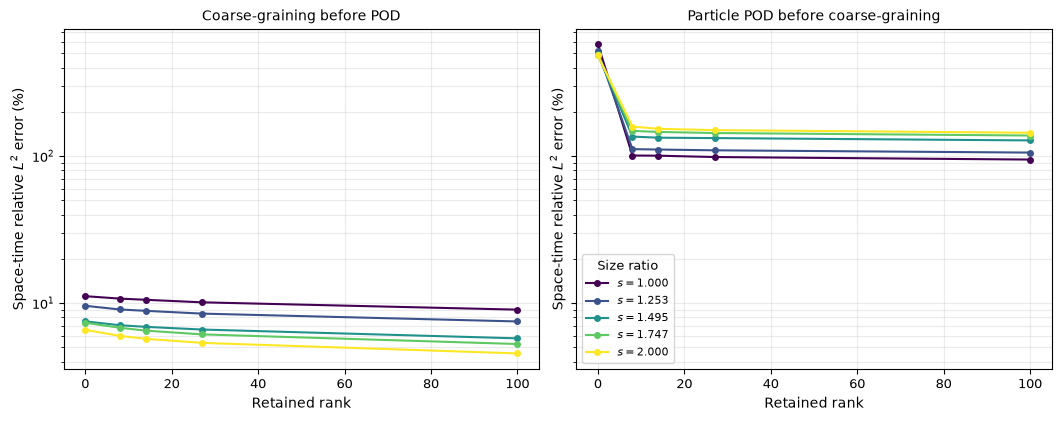

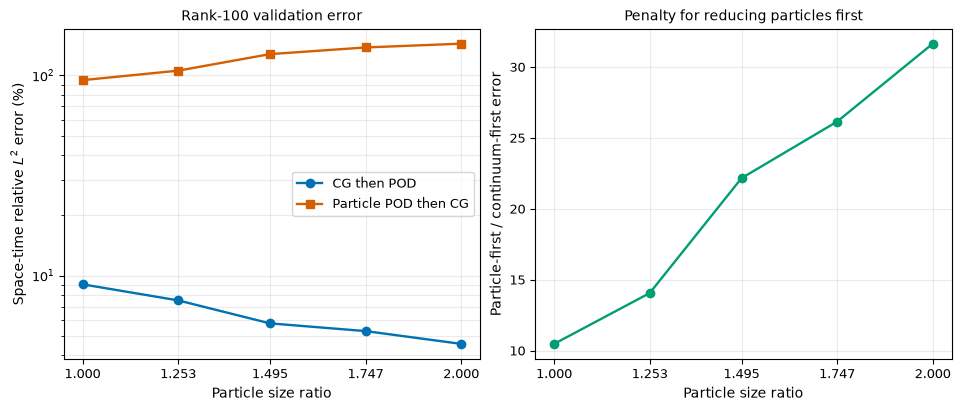

Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/multi_parameter_route_order/multi_parameter_route_order_error_by_rank.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/multi_parameter_route_order/multi_parameter_route_order_error_by_rank.png
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/multi_parameter_route_order/multi_parameter_rank_100_parameter_trend.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/multi_parameter_route_order/multi_parameter_rank_100_parameter_trend.png


In [32]:
import matplotlib.pyplot as plt


RANK_ERROR_FIGURE_PDF = (
    MULTI_FIGURE_DIRECTORY
    / "multi_parameter_route_order_error_by_rank.pdf"
)

RANK_ERROR_FIGURE_PNG = (
    MULTI_FIGURE_DIRECTORY
    / "multi_parameter_route_order_error_by_rank.png"
)

RANK_100_TREND_FIGURE_PDF = (
    MULTI_FIGURE_DIRECTORY
    / "multi_parameter_rank_100_parameter_trend.pdf"
)

RANK_100_TREND_FIGURE_PNG = (
    MULTI_FIGURE_DIRECTORY
    / "multi_parameter_rank_100_parameter_trend.png"
)


size_ratios = np.sort(
    all_time_results[
        "size_ratio"
    ].unique()
)

ratio_colours = {
    ratio: plt.get_cmap(
        "viridis"
    )(
        index
        / (
            len(size_ratios)
            - 1
        )
    )
    for index, ratio
    in enumerate(
        size_ratios
    )
}


with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
    }
):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(10.5, 4.1),
        sharey=True,
        constrained_layout=True,
    )

    route_panels = [
        (
            "CG then POD",
            "Coarse-graining before POD",
        ),
        (
            "Particle POD then CG",
            "Particle POD before coarse-graining",
        ),
    ]

    for axis, (
        route_name,
        panel_title,
    ) in zip(
        axes,
        route_panels,
    ):
        route_data = (
            all_time_results.loc[
                all_time_results[
                    "route"
                ].eq(route_name)
            ]
        )

        for ratio in size_ratios:
            ratio_data = (
                route_data.loc[
                    np.isclose(
                        route_data[
                            "size_ratio"
                        ],
                        ratio,
                        rtol=0.0,
                        atol=1e-12,
                    )
                ]
                .sort_values("rank")
            )

            axis.semilogy(
                ratio_data["rank"],
                ratio_data[
                    "spacetime_relative_l2_error_percent"
                ],
                marker="o",
                linewidth=1.5,
                markersize=4,
                color=ratio_colours[
                    ratio
                ],
                label=(
                    rf"$s={ratio:.3f}$"
                ),
            )

        axis.set_title(
            panel_title
        )
        axis.set_xlabel(
            "Retained rank"
        )
        axis.set_ylabel(
            r"Space-time relative $L^2$ error (%)"
        )
        axis.grid(
            True,
            which="both",
            alpha=0.25,
        )

    axes[1].legend(
        title="Size ratio",
        loc="best",
    )

    figure.savefig(
        RANK_ERROR_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        RANK_ERROR_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 9,
    }
):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(9.5, 4.0),
        constrained_layout=True,
    )

    axes[0].semilogy(
        rank_100_summary[
            "size_ratio"
        ],
        rank_100_summary[
            "continuum_spacetime_error_percent"
        ],
        marker="o",
        linewidth=1.7,
        color="#0072B2",
        label="CG then POD",
    )

    axes[0].semilogy(
        rank_100_summary[
            "size_ratio"
        ],
        rank_100_summary[
            "particle_spacetime_error_percent"
        ],
        marker="s",
        linewidth=1.7,
        color="#D55E00",
        label="Particle POD then CG",
    )

    axes[0].set_title(
        "Rank-100 validation error"
    )
    axes[0].set_xlabel(
        "Particle size ratio"
    )
    axes[0].set_ylabel(
        r"Space-time relative $L^2$ error (%)"
    )
    axes[0].set_xticks(
        size_ratios
    )
    axes[0].grid(
        True,
        which="both",
        alpha=0.25,
    )
    axes[0].legend()

    axes[1].plot(
        rank_100_summary[
            "size_ratio"
        ],
        rank_100_summary[
            "particle_first_to_continuum_first_ratio"
        ],
        marker="o",
        linewidth=1.7,
        color="#009E73",
    )

    axes[1].set_title(
        "Penalty for reducing particles first"
    )
    axes[1].set_xlabel(
        "Particle size ratio"
    )
    axes[1].set_ylabel(
        "Particle-first / continuum-first error"
    )
    axes[1].set_xticks(
        size_ratios
    )
    axes[1].grid(
        True,
        alpha=0.25,
    )

    figure.savefig(
        RANK_100_TREND_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        RANK_100_TREND_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


print("Saved:", RANK_ERROR_FIGURE_PDF)
print("Saved:", RANK_ERROR_FIGURE_PNG)
print("Saved:", RANK_100_TREND_FIGURE_PDF)
print("Saved:", RANK_100_TREND_FIGURE_PNG)

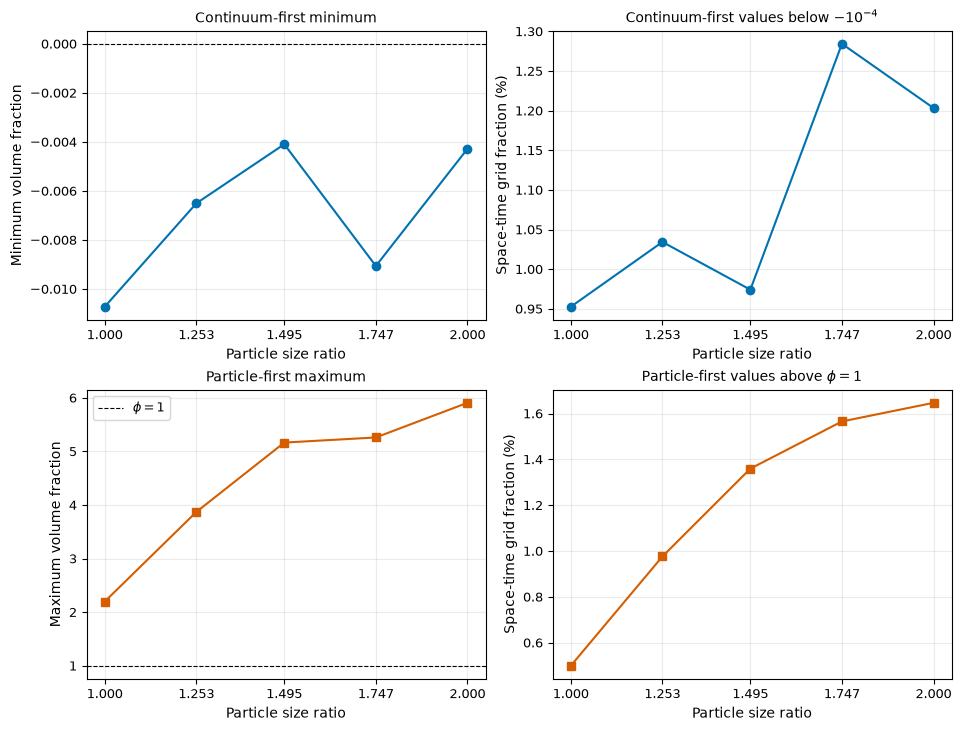

Rank-100 physical summary:


,case_id,size_ratio,continuum_minimum_volume_fraction,continuum_fraction_phi_lt_tolerance_percent,particle_maximum_volume_fraction,particle_fraction_phi_gt_one_percent
0,ratio_1_000000_num_1,1.000000,-0.010721,0.952626,2.197808,0.499394
1,ratio_1_252525_num_26,1.252525,-0.006505,1.034343,3.869961,0.976162
2,ratio_1_494949_num_50,1.494949,-0.004096,0.974141,5.164123,1.359495
3,ratio_1_747475_num_75,1.747475,-0.009059,1.284343,5.259810,1.565455
4,ratio_2_000000_num_100,2.000000,-0.004283,1.203333,5.906233,1.646768



Aggregate manifest: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/multi_parameter_route_order/multi_parameter_route_order_manifest.json
All aggregate tables and figures exist and are recorded by SHA-256.


In [33]:
PHYSICAL_SUMMARY_CSV = (
    MULTI_TABLE_DIRECTORY
    / "multi_parameter_rank_100_physical_summary.csv"
)

PHYSICAL_FIGURE_PDF = (
    MULTI_FIGURE_DIRECTORY
    / "multi_parameter_rank_100_physical_diagnostics.pdf"
)

PHYSICAL_FIGURE_PNG = (
    MULTI_FIGURE_DIRECTORY
    / "multi_parameter_rank_100_physical_diagnostics.png"
)

AGGREGATE_MANIFEST_PATH = (
    MULTI_TABLE_DIRECTORY
    / "multi_parameter_route_order_manifest.json"
)


physical_summary = (
    rank_100_summary[
        [
            "case_id",
            "size_ratio",
            "continuum_minimum_volume_fraction",
            "continuum_fraction_phi_lt_tolerance_percent",
            "particle_maximum_volume_fraction",
            "particle_fraction_phi_gt_one_percent",
        ]
    ]
    .copy()
)

write_csv_atomic(
    physical_summary,
    PHYSICAL_SUMMARY_CSV,
)


with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    }
):
    figure, axes = plt.subplots(
        2,
        2,
        figsize=(9.5, 7.2),
        constrained_layout=True,
    )

    axes[0, 0].plot(
        physical_summary[
            "size_ratio"
        ],
        physical_summary[
            "continuum_minimum_volume_fraction"
        ],
        marker="o",
        color="#0072B2",
    )

    axes[0, 0].axhline(
        0.0,
        color="black",
        linewidth=0.8,
        linestyle="--",
    )

    axes[0, 0].set_title(
        "Continuum-first minimum"
    )
    axes[0, 0].set_ylabel(
        "Minimum volume fraction"
    )

    axes[0, 1].plot(
        physical_summary[
            "size_ratio"
        ],
        physical_summary[
            "continuum_fraction_phi_lt_tolerance_percent"
        ],
        marker="o",
        color="#0072B2",
    )

    axes[0, 1].set_title(
        r"Continuum-first values below $-10^{-4}$"
    )
    axes[0, 1].set_ylabel(
        "Space-time grid fraction (%)"
    )

    axes[1, 0].plot(
        physical_summary[
            "size_ratio"
        ],
        physical_summary[
            "particle_maximum_volume_fraction"
        ],
        marker="s",
        color="#D55E00",
    )

    axes[1, 0].axhline(
        1.0,
        color="black",
        linewidth=0.8,
        linestyle="--",
        label=r"$\phi=1$",
    )

    axes[1, 0].set_title(
        "Particle-first maximum"
    )
    axes[1, 0].set_ylabel(
        "Maximum volume fraction"
    )
    axes[1, 0].legend()

    axes[1, 1].plot(
        physical_summary[
            "size_ratio"
        ],
        physical_summary[
            "particle_fraction_phi_gt_one_percent"
        ],
        marker="s",
        color="#D55E00",
    )

    axes[1, 1].set_title(
        r"Particle-first values above $\phi=1$"
    )
    axes[1, 1].set_ylabel(
        "Space-time grid fraction (%)"
    )

    for axis in axes.ravel():
        axis.set_xlabel(
            "Particle size ratio"
        )
        axis.set_xticks(
            size_ratios
        )
        axis.grid(
            True,
            alpha=0.25,
        )

    figure.savefig(
        PHYSICAL_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        PHYSICAL_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


aggregate_artifacts = {
    "master_average_csv":
        MASTER_AVERAGE_CSV,
    "master_time_csv":
        MASTER_TIME_CSV,
    "master_energy_csv":
        MASTER_ENERGY_CSV,
    "rank_100_summary_csv":
        RANK_100_SUMMARY_CSV,
    "rank_ratio_csv":
        RANK_RATIO_CSV,
    "rank_aggregate_csv":
        RANK_AGGREGATE_CSV,
    "physical_summary_csv":
        PHYSICAL_SUMMARY_CSV,
    "rank_error_figure_pdf":
        RANK_ERROR_FIGURE_PDF,
    "rank_error_figure_png":
        RANK_ERROR_FIGURE_PNG,
    "rank_100_trend_figure_pdf":
        RANK_100_TREND_FIGURE_PDF,
    "rank_100_trend_figure_png":
        RANK_100_TREND_FIGURE_PNG,
    "physical_figure_pdf":
        PHYSICAL_FIGURE_PDF,
    "physical_figure_png":
        PHYSICAL_FIGURE_PNG,
}

assert all(
    path.is_file()
    for path
    in aggregate_artifacts.values()
)


aggregate_manifest = {
    "schema_version":
        1,
    "notebook":
        "12_multi_parameter_route_order.ipynb",
    "experiment": {
        "case_count":
            5,
        "size_ratios":
            [
                float(value)
                for value in size_ratios
            ],
        "ranks":
            list(
                SELECTED_RANKS
            ),
        "training_snapshots_per_case":
            101,
        "validation_snapshots_per_case":
            99,
        "comparison_time_max":
            float(
                reference_time
            ),
        "particle_representation":
            "labelled XYZ coordinates",
        "continuum_representation":
            "small-species XZ volume fraction",
    },
    "pilot_regression": {
        "maximum_average_table_difference":
            float(
                maximum_average_difference
            ),
        "maximum_time_table_difference":
            float(
                maximum_time_difference
            ),
    },
    "descriptive_rank_100_trends": {
        "continuum_error_strictly_decreases":
            bool(
                np.all(
                    np.diff(
                        continuum_errors
                    )
                    < 0
                )
            ),
        "particle_error_strictly_increases":
            bool(
                np.all(
                    np.diff(
                        particle_errors
                    )
                    > 0
                )
            ),
        "error_ratio_strictly_increases":
            bool(
                np.all(
                    np.diff(
                        error_ratios
                    )
                    > 0
                )
            ),
        "continuum_error_range_percent": [
            float(
                continuum_errors.min()
            ),
            float(
                continuum_errors.max()
            ),
        ],
        "particle_error_range_percent": [
            float(
                particle_errors.min()
            ),
            float(
                particle_errors.max()
            ),
        ],
        "particle_to_continuum_error_ratio_range": [
            float(
                error_ratios.min()
            ),
            float(
                error_ratios.max()
            ),
        ],
    },
    "case_manifests": {
        case_id: {
            "relative_path":
                str(
                    checkpoint[
                        "paths"
                    ][
                        "manifest"
                    ].relative_to(
                        REPO_ROOT
                    )
                ),
            "sha256":
                sha256_file(
                    checkpoint[
                        "paths"
                    ][
                        "manifest"
                    ]
                ),
        }
        for case_id, checkpoint
        in all_case_checkpoints.items()
    },
    "aggregate_artifacts": {
        name: {
            "relative_path":
                str(
                    path.relative_to(
                        REPO_ROOT
                    )
                ),
            "sha256":
                sha256_file(
                    path
                ),
        }
        for name, path
        in aggregate_artifacts.items()
    },
}


temporary_manifest_path = (
    AGGREGATE_MANIFEST_PATH
    .with_suffix(
        ".tmp.json"
    )
)

with temporary_manifest_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        aggregate_manifest,
        handle,
        indent=2,
    )

temporary_manifest_path.replace(
    AGGREGATE_MANIFEST_PATH
)


print("Rank-100 physical summary:")

display(
    physical_summary
)

print(
    "\nAggregate manifest:",
    AGGREGATE_MANIFEST_PATH,
)

print(
    "All aggregate tables and figures "
    "exist and are recorded by SHA-256."
)

assert (
    aggregate_manifest[
        "pilot_regression"
    ][
        "maximum_time_table_difference"
    ]
    < 1e-10
)

## Final integrity audit

Re-read the aggregate manifest and verify the existence and SHA-256 digest of every case manifest, table and figure.


In [34]:
with AGGREGATE_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    final_manifest = json.load(handle)


audit_records = []

for section_name in [
    "case_manifests",
    "aggregate_artifacts",
]:
    for artifact_name, metadata in (
        final_manifest[
            section_name
        ].items()
    ):
        artifact_path = (
            REPO_ROOT
            / metadata["relative_path"]
        )

        exists = artifact_path.is_file()

        observed_hash = (
            sha256_file(artifact_path)
            if exists
            else None
        )

        audit_records.append(
            {
                "section":
                    section_name,
                "artifact":
                    artifact_name,
                "exists":
                    exists,
                "hash_matches":
                    (
                        observed_hash
                        == metadata["sha256"]
                    ),
            }
        )


artifact_audit = pd.DataFrame(
    audit_records
)


display(artifact_audit)


assert all_average_results.shape[0] == 50
assert all_time_results.shape[0] == 50
assert all_energy_results.shape[0] == 25

assert not all_average_results.duplicated(
    [
        "case_id",
        "route",
        "rank",
    ]
).any()

assert not all_time_results.duplicated(
    [
        "case_id",
        "route",
        "rank",
    ]
).any()

assert not all_energy_results.duplicated(
    [
        "case_id",
        "rank",
    ]
).any()

assert artifact_audit["exists"].all()
assert artifact_audit["hash_matches"].all()


print(
    "Final integrity audit passed:",
    f"{len(artifact_audit)} artifacts verified.",
)

print(
    "Notebook 12 multi-parameter analysis complete."
)

,section,artifact,exists,hash_matches
0,case_manifests,ratio_1_000000_num_1,True,True
1,case_manifests,ratio_1_252525_num_26,True,True
2,case_manifests,ratio_1_494949_num_50,True,True
3,case_manifests,ratio_1_747475_num_75,True,True
4,case_manifests,ratio_2_000000_num_100,True,True
5,aggregate_artifacts,master_average_csv,True,True
6,aggregate_artifacts,master_time_csv,True,True
7,aggregate_artifacts,master_energy_csv,True,True
8,aggregate_artifacts,rank_100_summary_csv,True,True
9,aggregate_artifacts,rank_ratio_csv,True,True


Final integrity audit passed: 18 artifacts verified.
Notebook 12 multi-parameter analysis complete.


## Multi-parameter conclusion

Across the five tested particle-size ratios, coarse-graining before POD
consistently produced the more accurate reduced representation. At rank
100, its space-time relative error decreased from 9.04% to 4.56% as the
size ratio increased. In contrast, particle-coordinate POD before
coarse-graining produced errors between 94.76% and 144.20%.

The particle-first error penalty therefore increased from 10.48 to 31.64
times the continuum-first error. The distinction was also physical:
particle-first reconstructions generated local volume fractions much
greater than one, with maxima increasing from 2.20 to 5.91. This suggests
that linear reconstruction of particle coordinates does not adequately
preserve exclusion, packing, or neighbourhood structure.

Continuum-field POD introduced small negative volume-fraction values, as
expected from an unconstrained linear basis. However, these violations
were comparatively small and affected only approximately 0.95–1.28% of
the evaluated space-time grid below the chosen tolerance.

These findings apply to the five selected parameter cases, the retained
ranks, the coordinate-POD formulation, and the coarse-graining settings
used here. They demonstrate that coarse-graining and dimensionality
reduction are not interchangeable operations in this particle system.